In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer

from semopy import Model
from semopy import calc_stats

from scipy.stats import f_oneway

In [2]:
import sys
print(sys.executable)

/Users/proghani/.pyenv/versions/3.12.9/bin/python


## Loading scales related to anhedonia

In [3]:
shaps_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_shaps01.csv')
teps_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_teps01.csv')
dass_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_dass01.csv')
qids_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_qids01.csv')
madrs_items = pd.read_csv('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/imputed/imputed_madrs01.csv')

In [4]:
dass_items.head()

,subjectkey,dass_p2_1,dass_p1_2,dass_p1_3,dass_p1_4,dass_p2_21,dass_p1_6,dass_p2_20,dass_p1_12,dass_p2_19,dass_p1_10,dass_p2_18,dass_p1_8,dass_p2_5,dass_p2_14,dass_p2_7,dass_p2_10,dass_p1_17,dass_p1_18,dass_p2_4,dass_p1_20,dass_p2_17,dass_p1_1,dass_p2_2,dass_p2_3,dass_p1_19,dass_p1_13,dass_p2_6,dass_p1_15,dass_p2_8,dass_p2_9,dass_p1_16,dass_p2_11,dass_p2_12,dass_p2_13,dass_p1_14,dass_p2_15,dass_p2_16,dass_p1_21,dass_p1_11,dass_p1_9,dass_p1_7,dass_p1_5
0,NDAR_INVDW733XXB,1,2,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,NDAR_INVPF308MTF,2,2,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,2,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,NDAR_INVEV975LY3,2,4,4,1,4,4,2,2,2,4,2,3,4,2,1,4,4,3,1,2,3,3,1,4,3,4,2,1,3,3,4,2,2,4,2,2,4,3,3,3,2,4
3,NDAR_INVRZ105MC1,2,4,1,2,1,2,1,1,1,1,1,3,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,2,1,1,2,2,1,1,1,1,1,1,2
4,NDAR_INVKV870NBK,1,1,1,1,2,2,1,2,2,1,2,2,1,1,1,1,2,1,1,1,1,2,1,1,1,1,1,2,2,2,1,2,2,2,3,1,1,1,1,1,1,2


In [5]:
shaps_items.columns

Index(['subjectkey', 'shaps1', 'shaps2', 'shaps3', 'shaps4', 'shaps5',
       'shaps6', 'shaps7', 'shaps8', 'shaps9', 'shaps10', 'shaps11', 'shaps12',
       'shaps13', 'shaps14'],
      dtype='str')

In [6]:
# Sum across the 14 items for each subject
shaps_items["shaps_total"] = shaps_items.loc[:, "shaps1":"shaps14"].sum(axis=1)

# Mean of the total scores across subjects
mean_shaps_total = shaps_items["shaps_total"].mean()

print("Mean SHAPS total score:", mean_shaps_total)


Mean SHAPS total score: 1.2787610619469028


In [7]:
teps_items.columns


Index(['subjectkey', 'teps1', 'teps2', 'teps3', 'teps4', 'teps5', 'teps6',
       'teps7', 'teps8', 'teps9', 'teps10', 'teps11', 'teps12', 'teps13',
       'teps14', 'teps15', 'teps16', 'teps17', 'teps18'],
      dtype='str')

In [8]:
teps_items.head()

,subjectkey,teps1,teps2,teps3,teps4,teps5,teps6,teps7,teps8,teps9,teps10,teps11,teps12,teps13,teps14,teps15,teps16,teps17,teps18
0,NDAR_INVDW733XXB,4,4,6,6,6,5,5,4,4,4,1,4,1,4,4,4,6,6
1,NDAR_INVPF308MTF,4,4,4,5,3,5,4,2,6,4,5,6,2,5,4,5,6,6
2,NDAR_INVEV975LY3,5,6,5,2,2,6,6,5,4,1,2,2,3,4,4,4,5,6
3,NDAR_INVRZ105MC1,1,6,4,6,6,6,6,6,1,3,4,5,1,4,6,6,4,6
4,NDAR_INVKV870NBK,6,6,6,5,6,6,4,4,6,5,1,3,1,5,5,6,6,6


### Reversing TEPS items
For the TEPS scale, higher scores indicate better hedonic capacity (less anhedonia), while for SHAPS/DASS/MADRS/QIDS, higher scores indicate worse anhedonia. I had already reversed the scores in item 13 which was based on the original documentation reverse-coded. 

In [9]:
# Reverse ALL TEPS items (including teps13) to align with other scales
# After reversal: higher scores = more anhedonia (less pleasure)
all_teps_items = ['teps1', 'teps2', 'teps3', 'teps4', 'teps5', 'teps6', 'teps7', 'teps8', 
                  'teps9', 'teps10', 'teps11', 'teps12', 'teps13', 'teps14', 'teps15', 
                  'teps16', 'teps17', 'teps18']

for item in all_teps_items:
    if item in teps_items.columns:
        teps_items[item] = 7 - teps_items[item]

#### calculating total anhendoni from DASS items
VariableName | TCP_var  | Description
--- | --- | ---
dass_3 | dass_p1_3 | I couldn't seem to experience any positive feeling at all
dass_10 | dass_p1_10 | I felt that I had nothing to look forward to
dass_16 | dass_p2_10 | I was unable to become enthusiastic about anything
dass_24 | dass_p2_3 | I couldn't seem to get any enjoyment out of the things I did
dass_31 | dass_p1_16 | I felt that I had lost interest in just about everything


### Identifying shared subjeckey values

#### Some changes
I removed MADRS and QIDS, because there is only one item from each that I was using in the factor analysis, but removing increases the number of participants in the intersection from 192 to 219

In [10]:
# Find the intersection of subjectkey values across all five DataFrames
shared_subjectkeys = set(shaps_items['subjectkey']).intersection(
    teps_items['subjectkey'],
    dass_items['subjectkey']
)

# Count the number of shared values
num_shared_subjectkeys = len(shared_subjectkeys)

# Print the result
print(f"Number of shared subjectkeys across all DataFrames: {num_shared_subjectkeys}")


Number of shared subjectkeys across all DataFrames: 219


In [11]:
# Filter rows where subjectkey is in shared_subjectkeys
subset = shaps_items[shaps_items["subjectkey"].isin(shared_subjectkeys)]

# Calculate total SHAPS per subject (14 items summed)
subset["shaps_total"] = subset.loc[:, "shaps1":"shaps14"].sum(axis=1)

# Mean of the totals across this subset
mean_shaps_total_subset = subset["shaps_total"].mean()

print("Mean SHAPS total (subset):", mean_shaps_total_subset)


Mean SHAPS total (subset): 1.2283105022831051


### Seaparting items related to anhedonia

#### Best Practice Approach: Bifactor Model for Anhedonia Clustering

Based on the recommendations from the methodology document, we'll implement a bifactor model that:
1. Uses individual items (not totals) to preserve measurement precision
2. Accounts for item weighting through proper factor modeling
3. Separates general anhedonia from specific anticipatory/consummatory facets
4. Uses polychoric correlations for ordinal data

In [12]:
# Define item mappings based on factor structure
# TEPS items
teps_anticipatory = ['teps1', 'teps4', 'teps6', 'teps8', 'teps10', 'teps11', 'teps15', 'teps16', 'teps18']
teps_consummatory = ['teps2', 'teps3', 'teps5', 'teps7', 'teps9', 'teps12', 'teps13', 'teps14', 'teps17']

# SHAPS items (all consummatory)
shaps_items_list = [f'shaps{i}' for i in range(1, 15)]

# DASS anhedonia items mapped to factors
dass_anticipatory = ['dass_p1_10', 'dass_p2_10', 'dass_p1_16']  # future-oriented
dass_consummatory = ['dass_p1_3', 'dass_p2_3']  # present-moment enjoyment

# # Single items
# qids_involvement = ['vintr']  # anticipatory
# madrs_inability = ['madrsfee']  # consummatory

print(f"TEPS Anticipatory: {len(teps_anticipatory)} items")
print(f"TEPS Consummatory: {len(teps_consummatory)} items")
print(f"SHAPS: {len(shaps_items_list)} items")
print(f"DASS Anticipatory: {len(dass_anticipatory)} items")
print(f"DASS Consummatory: {len(dass_consummatory)} items")
# print(f"QIDS: {len(qids_involvement)} items")
# print(f"MADRS: {len(madrs_inability)} items")

TEPS Anticipatory: 9 items
TEPS Consummatory: 9 items
SHAPS: 14 items
DASS Anticipatory: 3 items
DASS Consummatory: 2 items


In [13]:
# Prepare the merged dataset with individual items for the 192 shared subjects
# Start with SHAPS items
factor_data = shaps_items[shaps_items['subjectkey'].isin(shared_subjectkeys)][['subjectkey'] + shaps_items_list].copy()

# Add TEPS items
teps_subset = teps_items[teps_items['subjectkey'].isin(shared_subjectkeys)][['subjectkey'] + teps_anticipatory + teps_consummatory].copy()
factor_data = factor_data.merge(teps_subset, on='subjectkey')

# Add DASS items
dass_subset = dass_items[dass_items['subjectkey'].isin(shared_subjectkeys)][['subjectkey'] + dass_anticipatory + dass_consummatory].copy()
factor_data = factor_data.merge(dass_subset, on='subjectkey')

# # Add QIDS item
# qids_subset = qids_items[qids_items['subjectkey'].isin(shared_subjectkeys)][['subjectkey'] + qids_involvement].copy()
# factor_data = factor_data.merge(qids_subset, on='subjectkey')

# # Add MADRS item
# madrs_subset = madrs_items[madrs_items['subjectkey'].isin(shared_subjectkeys)][['subjectkey'] + madrs_inability].copy()
# factor_data = factor_data.merge(madrs_subset, on='subjectkey')


print(f"Final dataset shape: {factor_data.shape}")
print(f"Number of subjects: {len(factor_data)}")
print(f"Number of items (excluding subjectkey): {factor_data.shape[1] - 1}")

Final dataset shape: (219, 38)
Number of subjects: 219
Number of items (excluding subjectkey): 37


In [14]:
dass_subset.head()

,subjectkey,dass_p1_10,dass_p2_10,dass_p1_16,dass_p1_3,dass_p2_3
0,NDAR_INVDW733XXB,1,1,1,1,1
1,NDAR_INVPF308MTF,1,1,1,1,1
2,NDAR_INVEV975LY3,4,4,4,4,4
4,NDAR_INVKV870NBK,1,1,1,1,1
7,NDAR_INVXJ707NAE,1,1,1,1,1


In [15]:
# Verify scale alignment (all should have higher = worse anhedonia)
print("\nScale direction check - Total Scores (mean, SD, range):")

# SHAPS Total (sum of all 14 items)
shaps_total_vals = factor_data[shaps_items_list].sum(axis=1)
print(f"SHAPS Total: mean={shaps_total_vals.mean():.2f}, SD={shaps_total_vals.std():.2f}, range=({shaps_total_vals.min():.2f}, {shaps_total_vals.max():.2f})")

# TEPS Total (sum of all 18 reversed items)
teps_total_vals = factor_data[teps_anticipatory + teps_consummatory].sum(axis=1)
print(f"TEPS Total (reversed): mean={teps_total_vals.mean():.2f}, SD={teps_total_vals.std():.2f}, range=({teps_total_vals.min():.2f}, {teps_total_vals.max():.2f})")

# DASS Anhedonia Total (sum of 5 anhedonia items)
dass_total_vals = factor_data[dass_anticipatory + dass_consummatory].sum(axis=1)
print(f"DASS Anhedonia Total: mean={dass_total_vals.mean():.2f}, SD={dass_total_vals.std():.2f}, range=({dass_total_vals.min():.2f}, {dass_total_vals.max():.2f})")

print(f"\nSample size: n={len(factor_data)}")
print("Note: Higher scores indicate worse anhedonia for all scales after TEPS reversal")


Scale direction check - Total Scores (mean, SD, range):
SHAPS Total: mean=1.23, SD=2.36, range=(0.00, 12.00)
TEPS Total (reversed): mean=46.80, SD=11.93, range=(23.00, 87.00)
DASS Anhedonia Total: mean=7.57, SD=3.80, range=(5.00, 20.00)

Sample size: n=219
Note: Higher scores indicate worse anhedonia for all scales after TEPS reversal


In [16]:
factor_data.head()

,subjectkey,shaps1,shaps2,shaps3,shaps4,shaps5,shaps6,shaps7,shaps8,shaps9,shaps10,shaps11,shaps12,shaps13,shaps14,teps1,teps4,teps6,teps8,teps10,teps11,teps15,teps16,teps18,teps2,teps3,teps5,teps7,teps9,teps12,teps13,teps14,teps17,dass_p1_10,dass_p2_10,dass_p1_16,dass_p1_3,dass_p2_3
0,NDAR_INVDW733XXB,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,2,3,3,6,3,3,1,3,1,1,2,3,3,6,3,1,1,1,1,1,1
1,NDAR_INVPF308MTF,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,2,5,3,2,3,2,1,3,3,4,3,1,1,5,2,1,1,1,1,1,1
2,NDAR_INVEV975LY3,0,0,1,1,0,0,1,1,1,0,1,1,1,1,2,5,1,2,6,5,3,3,1,1,2,5,1,3,5,4,3,2,4,4,4,4,4
3,NDAR_INVKV870NBK,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,1,3,2,6,2,1,1,1,1,1,3,1,4,6,2,1,1,1,1,1,1
4,NDAR_INVXJ707NAE,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,1,4,4,3,1,1,1,1,1,3,1,2,3,6,1,1,1,1,1,1,1


In [17]:
# Mean of SHAPS totals (allowing missing items)
mean_shaps_total = factor_data.loc[:, 'shaps1':'shaps14'].sum(axis=1).mean()
print(mean_shaps_total)

1.2283105022831051


In [18]:
# Combine all anhedonia items
# General factor will load on all these items
anhedonia_items = (shaps_items_list + 
                  teps_anticipatory + teps_consummatory + 
                  dass_anticipatory + dass_consummatory)

# Specific factor groupings
anticipatory_items = teps_anticipatory + dass_anticipatory 
consummatory_items = teps_consummatory + shaps_items_list + dass_consummatory

print(f"Total anhedonia items: {len(anhedonia_items)}")
print(f"Anticipatory-specific items: {len(anticipatory_items)}")
print(f"Consummatory-specific items: {len(consummatory_items)}")

# Prepare data matrix (excluding subjectkey)
data_matrix = factor_data.drop('subjectkey', axis=1)
print(f"Data matrix shape: {data_matrix.shape}")
print(f"Available columns: {list(data_matrix.columns)}")

Total anhedonia items: 37
Anticipatory-specific items: 12
Consummatory-specific items: 25
Data matrix shape: (219, 37)
Available columns: ['shaps1', 'shaps2', 'shaps3', 'shaps4', 'shaps5', 'shaps6', 'shaps7', 'shaps8', 'shaps9', 'shaps10', 'shaps11', 'shaps12', 'shaps13', 'shaps14', 'teps1', 'teps4', 'teps6', 'teps8', 'teps10', 'teps11', 'teps15', 'teps16', 'teps18', 'teps2', 'teps3', 'teps5', 'teps7', 'teps9', 'teps12', 'teps13', 'teps14', 'teps17', 'dass_p1_10', 'dass_p2_10', 'dass_p1_16', 'dass_p1_3', 'dass_p2_3']


## Factor analysis


In [19]:
# 1. Check factorability of the data
# Test if data is suitable for factor analysis
chi_square_value, p_value = calculate_bartlett_sphericity(data_matrix)
kmo_all, kmo_model = calculate_kmo(data_matrix)

print(f"Bartlett's test: χ² = {chi_square_value:.2f}, p = {p_value:.4f}")
print(f"KMO measure: {kmo_model:.3f}")

if kmo_model < 0.6:
    print("Warning: KMO < 0.6 suggests data may not be suitable for factor analysis")

Bartlett's test: χ² = 3985.68, p = 0.0000
KMO measure: 0.852


/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


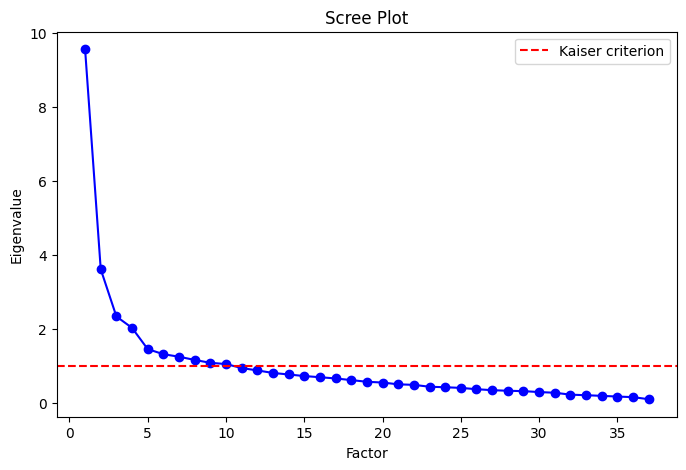

In [20]:
# 2. Exploratory Factor Analysis to determine structure
# First, determine optimal number of factors
fa = FactorAnalyzer(n_factors=data_matrix.shape[1], rotation=None)
fa.fit(data_matrix)

# Get eigenvalues for scree plot
ev, v = fa.get_eigenvalues()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ev)+1), ev, 'bo-')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser criterion')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.legend()
plt.show()

In [21]:
# 3. Fit 3-factor model
# Using 3 factors total with appropriate rotation
fa_3factor = FactorAnalyzer(n_factors=3, rotation='varimax')
fa_3factor.fit(data_matrix)

# Get loadings
loadings = pd.DataFrame(
    fa_3factor.loadings_,
    index=data_matrix.columns,
    columns=['Factor1', 'Factor2', 'Factor3']
)

In [22]:
# 4. Identify which factor represents what
# Check which items load on each factor
for factor in loadings.columns:
    print(f"\n{factor} - Top loading items:")
    top_items = loadings.nlargest(10, factor)[factor]
    for item, loading in top_items.items():
        item_type = 'Anticipatory' if item in anticipatory_items else 'Consummatory'
        print(f"  {item} ({item_type}): {loading:.3f}")


Factor1 - Top loading items:
  dass_p1_16 (Anticipatory): 0.884
  dass_p1_10 (Anticipatory): 0.857
  dass_p2_3 (Consummatory): 0.820
  dass_p2_10 (Anticipatory): 0.817
  dass_p1_3 (Consummatory): 0.777
  teps4 (Anticipatory): 0.698
  shaps3 (Consummatory): 0.578
  shaps5 (Consummatory): 0.444
  shaps4 (Consummatory): 0.406
  shaps11 (Consummatory): 0.393

Factor2 - Top loading items:
  teps16 (Anticipatory): 0.674
  teps15 (Anticipatory): 0.643
  teps14 (Consummatory): 0.574
  teps17 (Consummatory): 0.562
  teps18 (Anticipatory): 0.547
  teps2 (Consummatory): 0.516
  teps6 (Anticipatory): 0.477
  teps9 (Consummatory): 0.475
  teps8 (Anticipatory): 0.472
  teps12 (Consummatory): 0.432

Factor3 - Top loading items:
  shaps11 (Consummatory): 0.638
  shaps14 (Consummatory): 0.612
  shaps1 (Consummatory): 0.605
  shaps10 (Consummatory): 0.594
  shaps8 (Consummatory): 0.571
  shaps2 (Consummatory): 0.551
  shaps13 (Consummatory): 0.461
  shaps4 (Consummatory): 0.452
  shaps9 (Consummatory):

In [23]:
# 5. Extract factor scores for each participant
factor_scores = fa_3factor.transform(data_matrix)
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=['General_Anhedonia', 'Anticipatory', 'Consummatory']
)
factor_scores_df['subjectkey'] = factor_data['subjectkey'].values

In [24]:
# 6. Validate factor structure with confirmatory approach
# Check internal consistency
from sklearn.preprocessing import StandardScaler
import numpy as np

for items, name in [(anticipatory_items, 'Anticipatory'), 
                     (consummatory_items, 'Consummatory'),
                     (anhedonia_items, 'Total')]:
    if len(items) > 1:
        subset = data_matrix[items]
        # Calculate Cronbach's alpha
        item_variances = subset.var(axis=0, ddof=1)
        total_variance = subset.sum(axis=1).var(ddof=1)
        n_items = len(items)
        alpha = (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)
        print(f"{name} Cronbach's α = {alpha:.3f}")

Anticipatory Cronbach's α = 0.816
Consummatory Cronbach's α = 0.681
Total Cronbach's α = 0.838


In [25]:

# rather than empirically-derived factors
anticipatory_scores = data_matrix[anticipatory_items].mean(axis=1)
consummatory_scores = data_matrix[consummatory_items].mean(axis=1)
total_anhedonia_scores = data_matrix[anhedonia_items].mean(axis=1)

# Compare theory-driven vs empirical approaches
scores_df = pd.DataFrame({
    'subjectkey': factor_data['subjectkey'],
    'Factor1_empirical': factor_scores[:, 0],
    'Factor2_empirical': factor_scores[:, 1],
    'Factor3_empirical': factor_scores[:, 2],
    'Anticipatory_theory': anticipatory_scores,
    'Consummatory_theory': consummatory_scores,
    'Total_anhedonia': total_anhedonia_scores
})

# Check correlations
print("\nCorrelations between approaches:")
print(scores_df[['Factor1_empirical', 'Anticipatory_theory', 'Consummatory_theory']].corr())


Correlations between approaches:
                     Factor1_empirical  Anticipatory_theory  \
Factor1_empirical             1.000000             0.461011   
Anticipatory_theory           0.461011             1.000000   
Consummatory_theory           0.400329             0.586396   

                     Consummatory_theory  
Factor1_empirical               0.400329  
Anticipatory_theory             0.586396  
Consummatory_theory             1.000000  


The results confirm that the empirical factor structure doesn't align well with the theoretical anticipatory/consummatory distinction. The moderate correlations (0.46 and 0.40) between Factor 1 and your theory-driven scores, plus the high correlation (0.59) between anticipatory and consummatory scores, suggest these constructs aren't psychometrically distinct in your data.
This is actually consistent with recent critiques of the anticipatory/consummatory model in anhedonia research. The high overlap might reflect:

1. Shared method variance across scales
2. General anhedonia severity overshadowing subtype distinctions
3. The constructs being less separable than theory suggests



In [26]:
# GMM clustering with 2 components
from sklearn.mixture import GaussianMixture
import numpy as np

# Prepare factor scores for clustering (exclude subjectkey)
factor_scores_matrix = factor_scores_df[['General_Anhedonia', 'Anticipatory', 'Consummatory']].values

# Fit GMM with 2 components
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(factor_scores_matrix)

# Get cluster assignments and probabilities
cluster_labels = gmm.predict(factor_scores_matrix)
cluster_probabilities = gmm.predict_proba(factor_scores_matrix)

# Add to dataframe
factor_scores_df['gmm_cluster'] = cluster_labels
factor_scores_df['max_probability'] = np.max(cluster_probabilities, axis=1)

print(f"GMM Clustering Results (2 clusters):")
print(f"BIC: {gmm.bic(factor_scores_matrix):.2f}")
print(f"AIC: {gmm.aic(factor_scores_matrix):.2f}")

# Characterize clusters - need to merge with original data to get scale scores
cluster_results = factor_scores_df[['subjectkey', 'gmm_cluster', 'max_probability']].copy()
cluster_data_full = factor_data.merge(cluster_results, on='subjectkey')

# Calculate scale means for each cluster
for i in range(2):
    cluster_subset = cluster_data_full[cluster_data_full['gmm_cluster'] == i]
    print(f"\nCluster {i} (n={len(cluster_subset)}):")
    
    # Factor scores
    factor_subset = factor_scores_df[factor_scores_df['gmm_cluster'] == i]
    print(f"  General_Anhedonia: {factor_subset['General_Anhedonia'].mean():.3f} ± {factor_subset['General_Anhedonia'].std():.3f}")
    print(f"  Anticipatory: {factor_subset['Anticipatory'].mean():.3f} ± {factor_subset['Anticipatory'].std():.3f}")
    print(f"  Consummatory: {factor_subset['Consummatory'].mean():.3f} ± {factor_subset['Consummatory'].std():.3f}")
    
    # Scale means
    shaps_mean = cluster_subset[shaps_items_list].mean(axis=1).mean()
    teps_ant_mean = cluster_subset[teps_anticipatory].mean(axis=1).mean()
    teps_cons_mean = cluster_subset[teps_consummatory].mean(axis=1).mean()
    dass_mean = cluster_subset[dass_anticipatory + dass_consummatory].mean(axis=1).mean()
    
    print(f"  SHAPS mean: {shaps_mean:.3f}")
    print(f"  TEPS Anticipatory mean: {teps_ant_mean:.3f}")
    print(f"  TEPS Consummatory mean: {teps_cons_mean:.3f}")
    print(f"  DASS Anhedonia mean: {dass_mean:.3f}")
    print(f"  Avg probability: {factor_subset['max_probability'].mean():.3f}")

GMM Clustering Results (2 clusters):
BIC: 1322.26
AIC: 1257.87

Cluster 0 (n=97):
  General_Anhedonia: 0.733 ± 1.044
  Anticipatory: 0.104 ± 0.897
  Consummatory: 0.249 ± 1.300
  SHAPS mean: 0.188
  TEPS Anticipatory mean: 2.960
  TEPS Consummatory mean: 2.597
  DASS Anhedonia mean: 2.122
  Avg probability: 0.973

Cluster 1 (n=122):
  General_Anhedonia: -0.583 ± 0.174
  Anticipatory: -0.082 ± 0.936
  Consummatory: -0.198 ± 0.198
  SHAPS mean: 0.008
  TEPS Anticipatory mean: 2.520
  TEPS Consummatory mean: 2.397
  DASS Anhedonia mean: 1.031
  Avg probability: 0.970


In [27]:
# t-test for differences between clusters
from scipy import stats

# Get cluster data
cluster_0_data = cluster_data_full[cluster_data_full['gmm_cluster'] == 0]
cluster_1_data = cluster_data_full[cluster_data_full['gmm_cluster'] == 1]

print("T-tests for cluster differences:")
print("=" * 40)

# Test differences in scale means
scales = {
    'SHAPS': shaps_items_list,
    'TEPS_Anticipatory': teps_anticipatory,
    'TEPS_Consummatory': teps_consummatory,
    'DASS_Anhedonia': dass_anticipatory + dass_consummatory
}

for scale_name, items in scales.items():
    cluster_0_scores = cluster_0_data[items].mean(axis=1)
    cluster_1_scores = cluster_1_data[items].mean(axis=1)
    
    t_stat, p_val = stats.ttest_ind(cluster_0_scores, cluster_1_scores)
    
    # Calculate effect size (Cohen's d)
    pooled_std = np.sqrt(((len(cluster_0_scores) - 1) * cluster_0_scores.var() + 
                         (len(cluster_1_scores) - 1) * cluster_1_scores.var()) / 
                        (len(cluster_0_scores) + len(cluster_1_scores) - 2))
    cohens_d = (cluster_0_scores.mean() - cluster_1_scores.mean()) / pooled_std
    
    print(f"\n{scale_name}:")
    print(f"  Cluster 0: {cluster_0_scores.mean():.3f} ± {cluster_0_scores.std():.3f}")
    print(f"  Cluster 1: {cluster_1_scores.mean():.3f} ± {cluster_1_scores.std():.3f}")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, Cohen's d = {cohens_d:.3f}")

# Test differences in factor scores
factor_0_data = factor_scores_df[factor_scores_df['gmm_cluster'] == 0]
factor_1_data = factor_scores_df[factor_scores_df['gmm_cluster'] == 1]

print(f"\nFactor Scores:")
print("=" * 20)

for factor in ['General_Anhedonia', 'Anticipatory', 'Consummatory']:
    cluster_0_factor = factor_0_data[factor]
    cluster_1_factor = factor_1_data[factor]
    
    t_stat, p_val = stats.ttest_ind(cluster_0_factor, cluster_1_factor)
    
    # Calculate Cohen's d
    pooled_std = np.sqrt(((len(cluster_0_factor) - 1) * cluster_0_factor.var() + 
                         (len(cluster_1_factor) - 1) * cluster_1_factor.var()) / 
                        (len(cluster_0_factor) + len(cluster_1_factor) - 2))
    cohens_d = (cluster_0_factor.mean() - cluster_1_factor.mean()) / pooled_std
    
    print(f"\n{factor}:")
    print(f"  Cluster 0: {cluster_0_factor.mean():.3f} ± {cluster_0_factor.std():.3f}")
    print(f"  Cluster 1: {cluster_1_factor.mean():.3f} ± {cluster_1_factor.std():.3f}")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}, Cohen's d = {cohens_d:.3f}")

# Interpret effect sizes
print(f"\nEffect Size Interpretation:")
print("Cohen's d: 0.2 = small, 0.5 = medium, 0.8 = large")

T-tests for cluster differences:

SHAPS:
  Cluster 0: 0.188 ± 0.213
  Cluster 1: 0.008 ± 0.026
  t = 9.235, p = 0.0000, Cohen's d = 1.256

TEPS_Anticipatory:
  Cluster 0: 2.960 ± 0.920
  Cluster 1: 2.520 ± 0.809
  t = 3.761, p = 0.0002, Cohen's d = 0.512

TEPS_Consummatory:
  Cluster 0: 2.597 ± 0.652
  Cluster 1: 2.397 ± 0.703
  t = 2.156, p = 0.0322, Cohen's d = 0.293

DASS_Anhedonia:
  Cluster 0: 2.122 ± 0.795
  Cluster 1: 1.031 ± 0.089
  t = 15.040, p = 0.0000, Cohen's d = 2.046

Factor Scores:

General_Anhedonia:
  Cluster 0: 0.733 ± 1.044
  Cluster 1: -0.583 ± 0.174
  t = 13.694, p = 0.0000, Cohen's d = 1.863

Anticipatory:
  Cluster 0: 0.104 ± 0.897
  Cluster 1: -0.082 ± 0.936
  t = 1.487, p = 0.1385, Cohen's d = 0.202

Consummatory:
  Cluster 0: 0.249 ± 1.300
  Cluster 1: -0.198 ± 0.198
  t = 3.745, p = 0.0002, Cohen's d = 0.509

Effect Size Interpretation:
Cohen's d: 0.2 = small, 0.5 = medium, 0.8 = large


/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/737420517.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score', palette=['lightblue', 'lightcoral'], ax=axes[i])
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/737420517.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score', palette=['lightblue', 'lightcoral'], ax=axes[i])
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/737420517.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

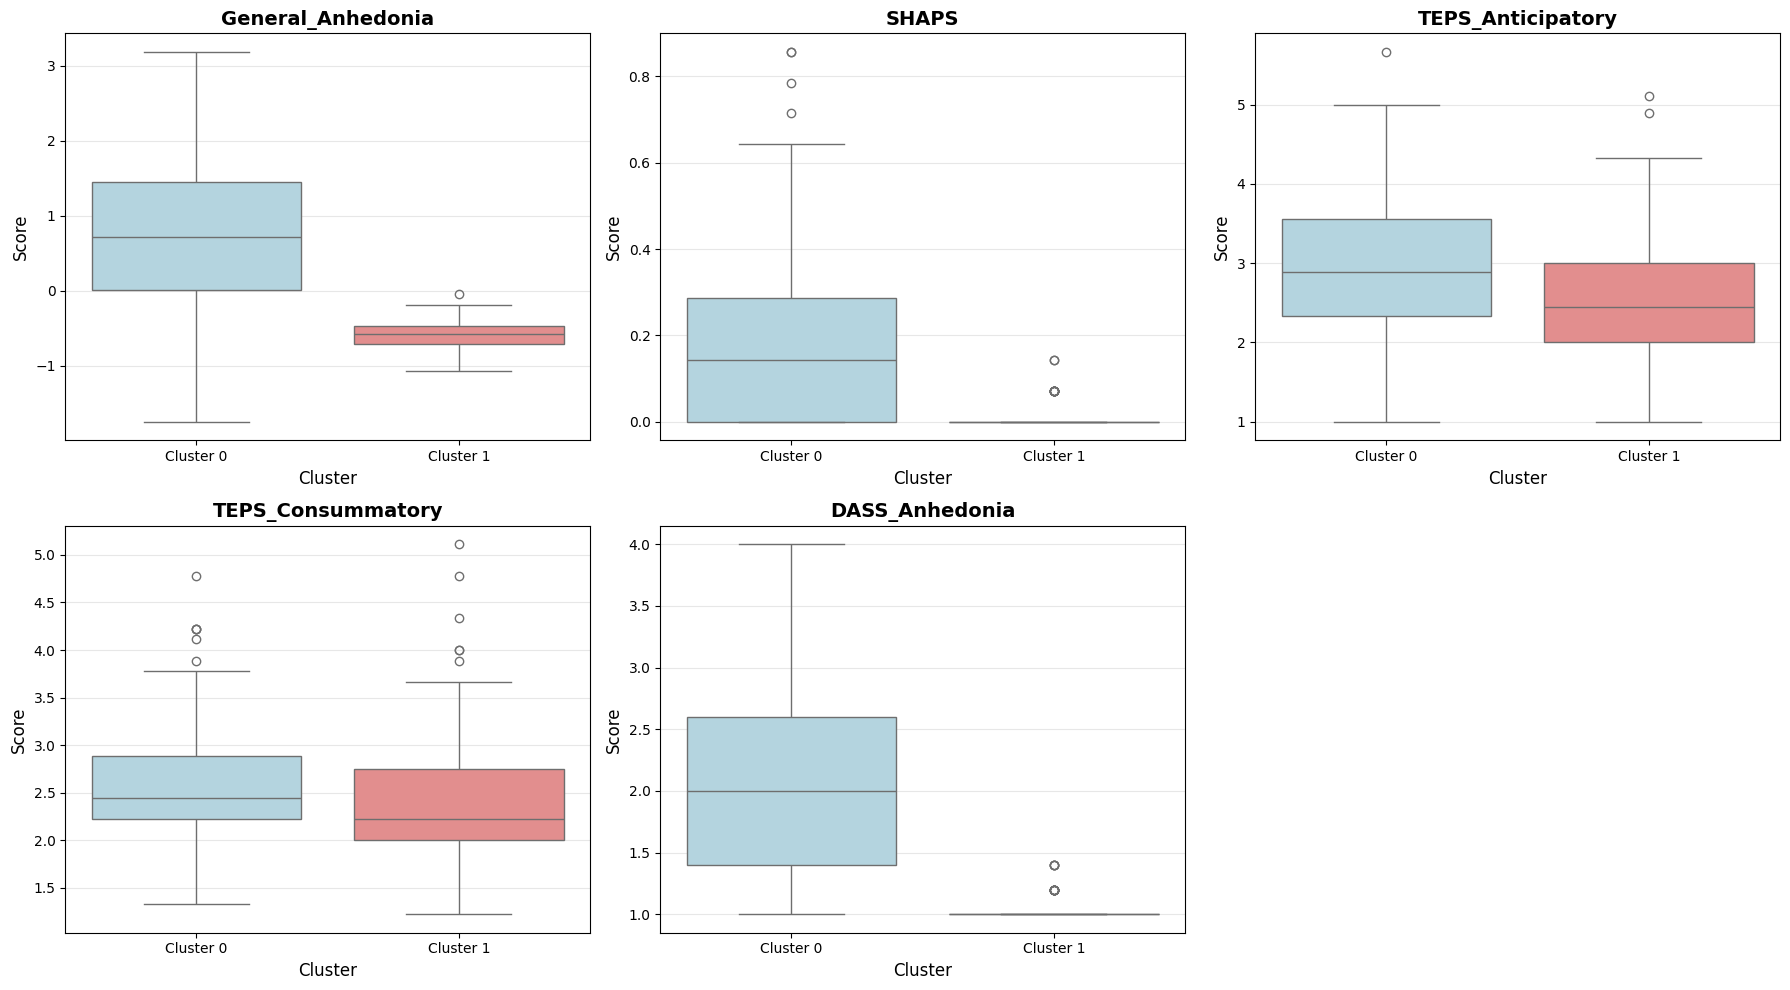

In [28]:
# Generate separate box plots for key measures
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = []

# Add General Anhedonia factor scores
for cluster in [0, 1]:
    factor_subset = factor_scores_df[factor_scores_df['gmm_cluster'] == cluster]
    for score in factor_subset['General_Anhedonia']:
        plot_data.append({
            'Measure': 'General_Anhedonia',
            'Cluster': f'Cluster {cluster}',
            'Score': score
        })

# Add scale means
scales = {
    'SHAPS': shaps_items_list,
    'TEPS_Anticipatory': teps_anticipatory,
    'TEPS_Consummatory': teps_consummatory,
    'DASS_Anhedonia': dass_anticipatory + dass_consummatory
}

for scale_name, items in scales.items():
    for cluster in [0, 1]:
        cluster_subset = cluster_data_full[cluster_data_full['gmm_cluster'] == cluster]
        scale_scores = cluster_subset[items].mean(axis=1)
        for score in scale_scores:
            plot_data.append({
                'Measure': scale_name,
                'Cluster': f'Cluster {cluster}',
                'Score': score
            })

# Convert to DataFrame
plot_df = pd.DataFrame(plot_data)

# Create separate box plots
measures = ['General_Anhedonia', 'SHAPS', 'TEPS_Anticipatory', 'TEPS_Consummatory', 'DASS_Anhedonia']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, measure in enumerate(measures):
    measure_data = plot_df[plot_df['Measure'] == measure]
    sns.boxplot(data=measure_data, x='Cluster', y='Score', palette=['lightblue', 'lightcoral'], ax=axes[i])
    axes[i].set_title(f'{measure}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=12)
    axes[i].set_ylabel('Score', fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)

# Remove the empty subplot
axes[5].remove()

plt.tight_layout()
plt.show()

In [29]:
# Save factor scores and cluster assignments to CSV
# factor_scores_df.to_csv('anhedonia_gmm_clusters.csv', index=False)


In [30]:
factor_scores_df.head()

,General_Anhedonia,Anticipatory,Consummatory,subjectkey,gmm_cluster,max_probability
0,-0.771573,0.299270,-0.276716,NDAR_INVDW733XXB,1,0.979893
1,-0.628963,0.045552,-0.130312,NDAR_INVPF308MTF,1,0.994174
2,3.183072,-0.510171,1.638215,NDAR_INVEV975LY3,0,1.000000
3,-0.510762,-0.651351,-0.186938,NDAR_INVKV870NBK,1,0.994368
4,-0.587057,-0.827855,-0.122989,NDAR_INVXJ707NAE,1,0.994245


## Polychoric EFA + Parallel Analysis (Codex additions)
This block computes a polychoric correlation matrix for the current item set, runs Horn's parallel analysis to suggest the optimal number of factors, and fits an EFA (principal axis factoring with varimax) on the polychoric matrix. It also compares the resulting loadings to the existing solution if available.

### What this block does
- Builds a polychoric correlation matrix for the current item set (`anhedonia_items`).
- Runs Horn's parallel analysis on that matrix to suggest the optimal factor count.
- Fits an Exploratory Factor Analysis using principal axis factoring (PAF) with varimax rotation on the polychoric matrix.
- Optionally compares loadings to your existing solution via Tucker congruence (if `fa_3factor` is present).

Computing polychoric correlation on 37 items (n=219)...
Polychoric correlation matrix computed.
Parallel Analysis suggests k = 4 factors (observed eigenvalues > 95th percentile random).


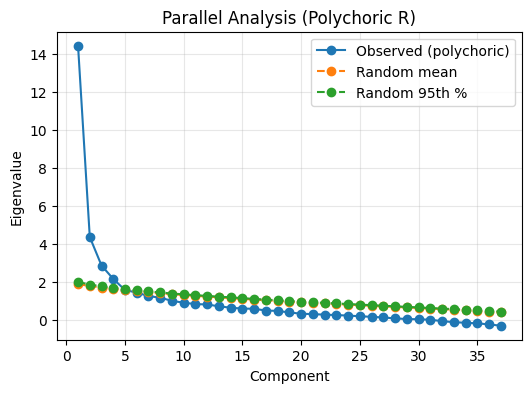


Polychoric-PAF Varimax Loadings (top 10 per factor):

Factor 1:
  dass_p1_16: 0.936
  dass_p1_10: 0.925
  dass_p2_3: 0.874
  dass_p2_10: 0.873
  dass_p1_3: 0.854
  shaps3: 0.761
  teps4: 0.748
  shaps11: 0.652
  shaps4: 0.648
  shaps13: 0.623

Factor 2:
  teps17: 0.702
  teps2: 0.688
  teps3: 0.635
  teps14: 0.613
  teps9: 0.601
  shaps6: 0.590
  teps16: 0.477
  shaps5: 0.444
  teps6: 0.428
  teps15: 0.395

Factor 3:
  teps8: 0.717
  teps15: 0.596
  teps18: 0.540
  teps10: 0.536
  teps11: 0.509
  teps16: 0.490
  shaps1: 0.432
  teps1: 0.421
  shaps2: 0.350
  shaps12: -0.332

Factor 4:
  shaps10: 0.898
  shaps14: 0.773
  shaps8: 0.724
  shaps11: 0.710
  shaps1: 0.700
  shaps2: 0.658
  shaps13: 0.650
  shaps9: 0.590
  shaps7: 0.523
  shaps12: 0.471

Tucker congruence (polychoric-PAF vs current loadings):


,Curr_F1,Curr_F2,Curr_F3
Poly_F1,0.981,0.432,0.725
Poly_F2,0.351,0.873,0.186
Poly_F3,0.255,0.760,0.477
Poly_F4,0.589,0.305,0.980


In [31]:
# Polychoric correlation + Parallel Analysis + EFA (on polychoric R)
import numpy as np
import pandas as pd
import warnings
from scipy import optimize
from scipy.stats import multivariate_normal, norm
import matplotlib.pyplot as plt

# ---------- Helpers: thresholds and polychoric for two variables ----------
def _thresholds_from_marginals(x):
    """Compute thresholds from marginal distribution of ordinal variable."""
    x = pd.Series(x).dropna().astype(float)
    cats, counts = np.unique(x, return_counts=True)
    probs = counts / counts.sum()
    cum = np.cumsum(probs)[:-1]  # exclude last (which would be 1)
    # clip to avoid infs at 0/1
    eps = 1e-6
    cum = np.clip(cum, eps, 1 - eps)
    taus = norm.ppf(cum)
    bounds = np.concatenate(([-np.inf], taus, [np.inf]))
    return cats, bounds

def _bvn_rect_prob(a, b, c, d, rho):
    """Compute bivariate normal rectangle probability."""
    cov = [[1.0, rho], [rho, 1.0]]
    # CDF up to corner points; rectangle probability via inclusion-exclusion
    p_bd = multivariate_normal.cdf([b, d], mean=[0, 0], cov=cov)
    p_ad = multivariate_normal.cdf([a, d], mean=[0, 0], cov=cov)
    p_bc = multivariate_normal.cdf([b, c], mean=[0, 0], cov=cov)
    p_ac = multivariate_normal.cdf([a, c], mean=[0, 0], cov=cov)
    p = p_bd - p_ad - p_bc + p_ac
    return max(p, 1e-12)

def polychoric_two_step(x, y, initial_r=None):
    """Two-step polychoric correlation via fixed thresholds from marginals and ML for rho."""
    x, y = pd.Series(x), pd.Series(y)
    mask = x.notna() & y.notna()
    x, y = x[mask].astype(float), y[mask].astype(float)
    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan
    x_cats, x_bounds = _thresholds_from_marginals(x)
    y_cats, y_bounds = _thresholds_from_marginals(y)
    # contingency counts
    xti = {v: i for i, v in enumerate(x_cats)}
    yti = {v: i for i, v in enumerate(y_cats)}
    Kx, Ky = len(x_cats), len(y_cats)
    counts = np.zeros((Kx, Ky), dtype=int)
    for xi, yi in zip(x, y):
        counts[xti[xi], yti[yi]] += 1
    # negative log-likelihood in rho
    def nll(rho):
        # guard rho bounds for numerical stability
        if not (-0.999 < rho < 0.999):
            return np.inf
        ll = 0.0
        for i in range(Kx):
            a, b = x_bounds[i], x_bounds[i+1]
            for j in range(Ky):
                c, d = y_bounds[j], y_bounds[j+1]
                pij = _bvn_rect_prob(a, b, c, d, rho)
                cnt = counts[i, j]
                if cnt:
                    ll += cnt * np.log(pij)
        return -ll
    if initial_r is None:
        initial_r = pd.Series(x).corr(pd.Series(y), method='pearson')
        if not np.isfinite(initial_r):
            initial_r = 0.0
    res = optimize.minimize_scalar(nll, bounds=(-0.99, 0.99), method='bounded', options={'xatol': 1e-3})
    return float(res.x) if res.success else float(initial_r)

def polychoric_corr_matrix(df):
    """Compute full polychoric correlation matrix."""
    cols = list(df.columns)
    p = len(cols)
    R = np.eye(p)
    for i in range(p):
        for j in range(i+1, p):
            r = polychoric_two_step(df[cols[i]], df[cols[j]])
            R[i, j] = R[j, i] = r
    return pd.DataFrame(R, index=cols, columns=cols)

# ---------- Parallel Analysis on correlation matrix ----------
def parallel_analysis(R, n_samples, n_iter=200, percentile=95, random_state=42):
    """Horn's parallel analysis for factor retention."""
    rng = np.random.default_rng(random_state)
    p = R.shape[0]
    # observed eigenvalues
    evals_obs = np.linalg.eigvalsh(R)[::-1]
    evals_rand = np.zeros((n_iter, p))
    for b in range(n_iter):
        X = rng.standard_normal(size=(n_samples, p))
        X = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
        Rb = np.corrcoef(X, rowvar=False)
        evals_rand[b] = np.linalg.eigvalsh(Rb)[::-1]
    evals_mean = evals_rand.mean(axis=0)
    evals_perc = np.percentile(evals_rand, percentile, axis=0)
    return evals_obs, evals_mean, evals_perc

# ---------- Principal Axis Factoring with varimax rotation ----------
def smc_communalities(R):
    """Compute squared multiple correlations as initial communality estimates."""
    try:
        invR = np.linalg.inv(R)
        smc = 1 - 1 / np.diag(invR)
        return np.clip(smc, 0.0, 0.99)
    except np.linalg.LinAlgError:
        # fallback: R may be near-singular
        return np.clip(1 - 1 / np.diag(np.linalg.pinv(R)), 0.0, 0.99)

def principal_axis_factor(R, n_factors, tol=1e-4, max_iter=100):
    """Principal axis factoring (PAF) algorithm."""
    R = np.array(R, dtype=float)
    p = R.shape[0]
    h2 = smc_communalities(R)
    for _ in range(max_iter):
        R_star = R.copy()
        np.fill_diagonal(R_star, h2)
        evals, evecs = np.linalg.eigh(R_star)
        idx = np.argsort(evals)[::-1]
        evals, evecs = evals[idx], evecs[:, idx]
        L = evecs[:, :n_factors] * np.sqrt(np.maximum(evals[:n_factors], 0))
        h2_new = np.sum(L**2, axis=1)
        if np.max(np.abs(h2_new - h2)) < tol:
            break
        h2 = h2_new
    return L

def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    """Kaiser (1958) varimax rotation."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda))) )
        R = u @ vh
        d = np.sum(s)
        if d_old != 0 and d/d_old < 1 + tol:
            break
    return Phi @ R

def tucker_congruence_matrix(L1, L2):
    """Compute Tucker congruence coefficients between factor loading matrices."""
    # columns = factors
    F1, F2 = L1.shape[1], L2.shape[1]
    C = np.zeros((F1, F2))
    for i in range(F1):
        a = L1[:, i]
        for j in range(F2):
            b = L2[:, j]
            num = np.dot(a, b)
            den = np.sqrt(np.dot(a, a) * np.dot(b, b))
            C[i, j] = num / den if den > 0 else np.nan
    return C

# ---------- Prepare data ----------
assert 'factor_data' in globals(), 'factor_data not found. Run previous cells to build the item matrix.'
assert 'anhedonia_items' in globals(), 'anhedonia_items not found. Run previous cells that define item lists.'
X = factor_data[anhedonia_items].copy()
n, p = X.shape
print(f'Computing polychoric correlation on {p} items (n={n})...')

# ---------- Compute polychoric correlation matrix ----------
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    R_poly = polychoric_corr_matrix(X)

print('Polychoric correlation matrix computed.')

# ---------- Parallel analysis ----------
evals_obs, evals_mean, evals_p95 = parallel_analysis(R_poly.values, n_samples=n, n_iter=200, percentile=95)
k_pa = int(np.sum(evals_obs > evals_p95))
print(f'Parallel Analysis suggests k = {k_pa} factors (observed eigenvalues > 95th percentile random).')

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.arange(1, p+1), evals_obs, 'o-', label='Observed (polychoric)')
ax.plot(np.arange(1, p+1), evals_mean, 'o--', label='Random mean')
ax.plot(np.arange(1, p+1), evals_p95, 'o--', label='Random 95th %')
ax.set_xlabel('Component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Parallel Analysis (Polychoric R)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# ---------- EFA on polychoric R (PAF + varimax) ----------
k_use = max(1, k_pa)
L_paf = principal_axis_factor(R_poly.values, n_factors=k_use)
L_rot = varimax(L_paf)
loadings_poly = pd.DataFrame(L_rot, index=anhedonia_items, columns=[f'Factor{i+1}' for i in range(k_use)])

print('\nPolychoric-PAF Varimax Loadings (top 10 per factor):')
for j in range(k_use):
    col = loadings_poly.iloc[:, j]
    top = col.abs().sort_values(ascending=False).head(10)
    print(f'\nFactor {j+1}:')
    for item in top.index:
        print(f'  {item}: {col[item]:.3f}')

# ---------- Compare to existing solution if available ----------
if 'fa_3factor' in globals():
    try:
        # Align to same items order as loadings_poly
        loadings_current = pd.DataFrame(fa_3factor.loadings_, index=factor_data.drop('subjectkey', axis=1).columns)
        loadings_current = loadings_current.reindex(loadings_poly.index)
        C = tucker_congruence_matrix(loadings_poly.values, loadings_current.values)
        print('\nTucker congruence (polychoric-PAF vs current loadings):')
        C_df = pd.DataFrame(C, index=[f'Poly_F{i+1}' for i in range(loadings_poly.shape[1])],
                          columns=[f'Curr_F{i+1}' for i in range(loadings_current.shape[1])])
        display(C_df.round(3))
    except Exception as e:
        print('Comparison to current loadings skipped due to error:', e)
else:
    print('No existing fa_3factor found; skipping congruence comparison.')

In [32]:
# Extract factor scores from the 4-factor polychoric solution
# Compute factor scores using regression method
def compute_factor_scores(data_matrix, loadings, correlation_matrix):
    """Compute factor scores using regression method."""
    # Factor score coefficients: B = R^-1 * L * (L' * R^-1 * L)^-1
    R_inv = np.linalg.pinv(correlation_matrix.values)
    L = loadings.values
    factor_score_coeff = R_inv @ L @ np.linalg.pinv(L.T @ R_inv @ L)
    
    # Standardize the data
    data_std = (data_matrix - data_matrix.mean()) / data_matrix.std()
    
    # Compute factor scores
    factor_scores = data_std.values @ factor_score_coeff
    return factor_scores

# Get factor scores for the 4-factor solution
factor_scores_poly = compute_factor_scores(X, loadings_poly, R_poly)

# Create DataFrame with factor scores
factor_scores_poly_df = pd.DataFrame(
    factor_scores_poly,
    columns=[f'PolyFactor{i+1}' for i in range(4)],
    index=X.index
)

# Add subject IDs
factor_scores_poly_df['subjectkey'] = factor_data['subjectkey'].values

print("Polychoric 4-factor scores computed:")
print(factor_scores_poly_df.head())
print(f"Shape: {factor_scores_poly_df.shape}")

# Basic descriptive statistics
print("\nFactor score descriptives:")
for col in factor_scores_poly_df.columns[:-1]:  # exclude subjectkey
    scores = factor_scores_poly_df[col]
    print(f"{col}: Mean={scores.mean():.3f}, SD={scores.std():.3f}, Range=[{scores.min():.3f}, {scores.max():.3f}]")

Polychoric 4-factor scores computed:
   PolyFactor1  PolyFactor2  PolyFactor3  PolyFactor4        subjectkey
0    -0.574557     0.183276     0.347033     0.128889  NDAR_INVDW733XXB
1    -0.628810     0.134097     0.019840     0.104502  NDAR_INVPF308MTF
2     4.079577    -1.376646    -1.525562     0.686356  NDAR_INVEV975LY3
3    -0.704137    -0.389698    -0.466207     0.157681  NDAR_INVKV870NBK
4    -1.267788    -0.146752     0.146322     0.393253  NDAR_INVXJ707NAE
Shape: (219, 5)

Factor score descriptives:
PolyFactor1: Mean=-0.000, SD=1.687, Range=[-4.701, 7.201]
PolyFactor2: Mean=0.000, SD=1.361, Range=[-4.436, 5.592]
PolyFactor3: Mean=-0.000, SD=1.125, Range=[-3.934, 3.959]
PolyFactor4: Mean=0.000, SD=1.013, Range=[-2.582, 4.404]


In [33]:
# =============================================================================
# Export polychoric R matrix and factor loadings for use in additional_analyses.ipynb
# =============================================================================
R_poly.to_csv('polychoric_R_matrix.csv')
loadings_poly.to_csv('polychoric_factor_loadings.csv')
print(f"Saved polychoric_R_matrix.csv ({R_poly.shape})")
print(f"Saved polychoric_factor_loadings.csv ({loadings_poly.shape})")

Saved polychoric_R_matrix.csv ((37, 37))
Saved polychoric_factor_loadings.csv ((37, 4))


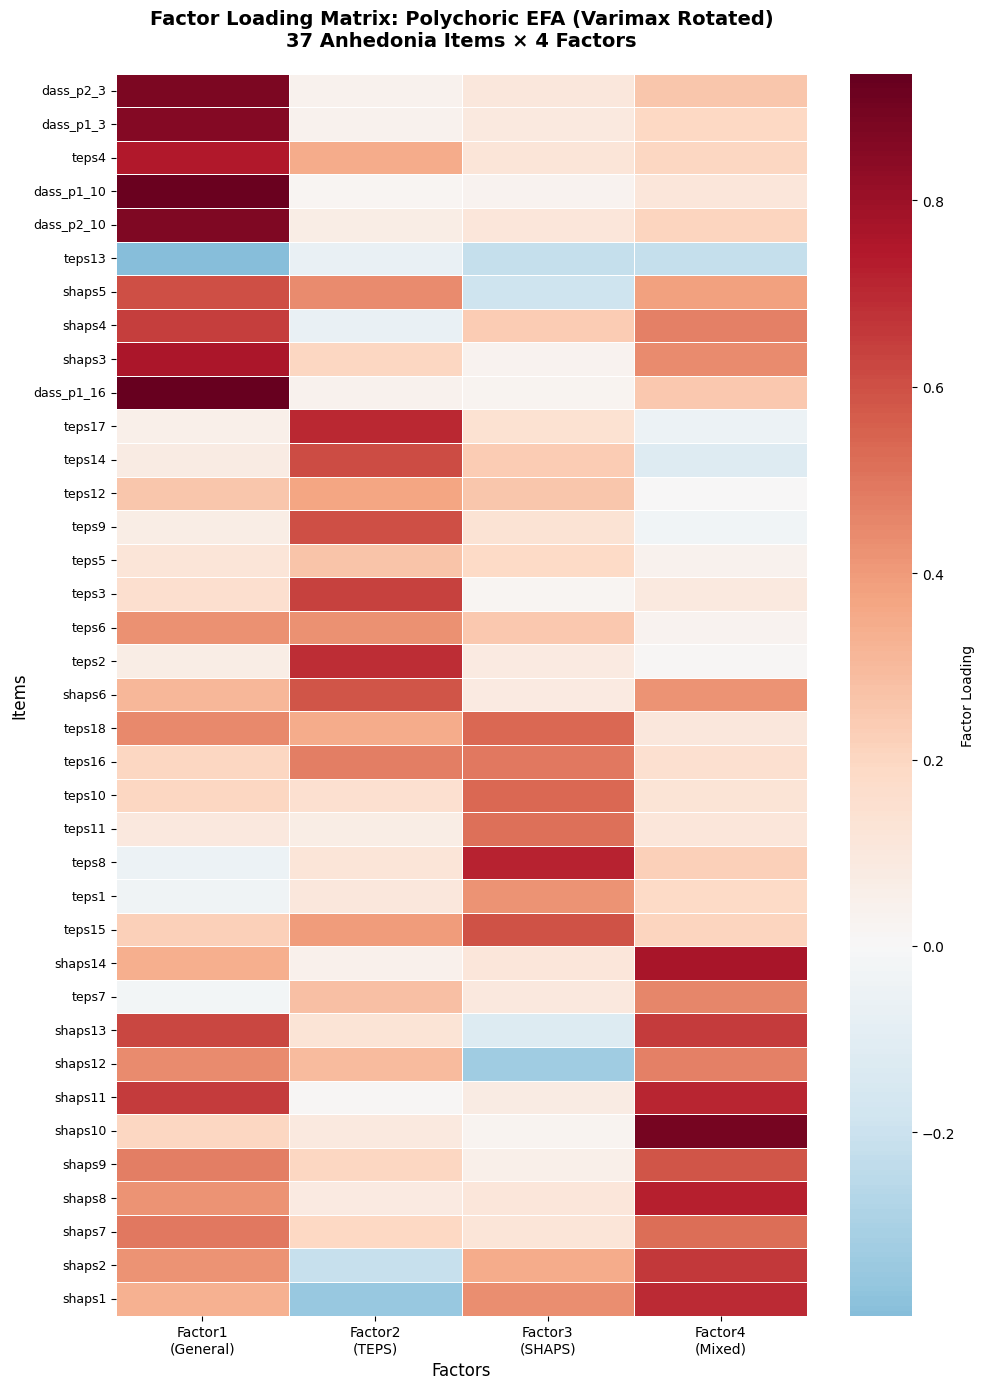

Factor Loading Heatmap Summary:
Items with loadings ≥ 0.40:

Factor1:
  dass_p1_16: 0.936
  dass_p1_10: 0.925
  dass_p2_3: 0.874
  dass_p2_10: 0.873
  dass_p1_3: 0.854
  shaps3: 0.761
  teps4: 0.748
  shaps11: 0.652
  shaps4: 0.648
  shaps13: 0.623
  shaps5: 0.603
  shaps7: 0.493
  shaps9: 0.480
  teps18: 0.448
  shaps12: 0.445
  teps6: 0.428
  shaps2: 0.417
  shaps8: 0.416

Factor2:
  teps17: 0.702
  teps2: 0.688
  teps3: 0.635
  teps14: 0.613
  teps9: 0.601
  shaps6: 0.590
  teps16: 0.477
  shaps5: 0.444
  teps6: 0.428

Factor3:
  teps8: 0.717
  teps15: 0.596
  teps18: 0.540
  teps10: 0.536
  teps11: 0.509
  teps16: 0.490
  shaps1: 0.432
  teps1: 0.421

Factor4:
  shaps10: 0.898
  shaps14: 0.773
  shaps8: 0.724
  shaps11: 0.710
  shaps1: 0.700
  shaps2: 0.658
  shaps13: 0.650
  shaps9: 0.590
  shaps7: 0.523
  shaps12: 0.471
  shaps4: 0.469
  teps7: 0.455
  shaps3: 0.438
  shaps6: 0.420

Number of salient loadings (≥0.40) per factor:
Factor1: 18 items
Factor2: 9 items
Factor3: 8 items

In [34]:
# Factor Loading Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the factor loadings from polychoric analysis
loadings_heatmap = loadings_poly.copy()

# Sort items by their highest loading factor for better visualization
factor_assignments = loadings_heatmap.abs().idxmax(axis=1)
loadings_sorted = loadings_heatmap.loc[factor_assignments.sort_values().index]

# Create the heatmap
plt.figure(figsize=(10, 14))

# Create heatmap with custom colormap
sns.heatmap(loadings_sorted, 
            annot=False,   # turn off values inside heatmap
            cmap='RdBu_r', 
            center=0,
            cbar_kws={'label': 'Factor Loading'},
            linewidths=0.5)

plt.title('Factor Loading Matrix: Polychoric EFA (Varimax Rotated)\n37 Anhedonia Items × 4 Factors', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Items', fontsize=12)

# Rotate y-axis labels for better readability
plt.yticks(rotation=0, fontsize=9)
plt.xticks(rotation=0, fontsize=10)

# Add factor interpretation labels
factor_labels = ['Factor1\n(General)', 'Factor2\n(TEPS)', 'Factor3\n(SHAPS)', 'Factor4\n(Mixed)']
ax = plt.gca()
ax.set_xticklabels(factor_labels)

# Adjust layout
plt.tight_layout()
plt.show()

# Print some summary statistics
print("Factor Loading Heatmap Summary:")
print("=" * 40)
print(f"Items with loadings ≥ 0.40:")
for factor in loadings_poly.columns:
    high_loaders = loadings_poly[loadings_poly[factor].abs() >= 0.40][factor]
    if len(high_loaders) > 0:
        print(f"\n{factor}:")
        for item, loading in high_loaders.sort_values(key=abs, ascending=False).items():
            print(f"  {item}: {loading:.3f}")
            
# Count of salient loadings per factor
print(f"\nNumber of salient loadings (≥0.40) per factor:")
for factor in loadings_poly.columns:
    count = (loadings_poly[factor].abs() >= 0.40).sum()
    print(f"{factor}: {count} items")

In [35]:
# GMM clustering with the 4-factor polychoric solution - FIXED TO 2 CLUSTERS
from sklearn.mixture import GaussianMixture
import numpy as np

# Prepare factor scores for clustering (exclude subjectkey)
factor_scores_matrix_poly = factor_scores_poly_df[['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']].values

# Fit GMM with 2 clusters (as requested)
gmm_poly = GaussianMixture(n_components=2, random_state=42)
gmm_poly.fit(factor_scores_matrix_poly)

# Get cluster assignments and probabilities
cluster_labels_poly = gmm_poly.predict(factor_scores_matrix_poly)
cluster_probabilities_poly = gmm_poly.predict_proba(factor_scores_matrix_poly)

# Add to dataframe
factor_scores_poly_df['gmm_cluster'] = cluster_labels_poly
factor_scores_poly_df['max_probability'] = np.max(cluster_probabilities_poly, axis=1)

print(f"GMM Clustering Results (2 clusters):")
print(f"BIC: {gmm_poly.bic(factor_scores_matrix_poly):.2f}")
print(f"AIC: {gmm_poly.aic(factor_scores_matrix_poly):.2f}")

GMM Clustering Results (2 clusters):
BIC: 2484.04
AIC: 2385.76


In [36]:
# Characterize the polychoric-based clusters - 2 CLUSTERS
cluster_results_poly = factor_scores_poly_df[['subjectkey', 'gmm_cluster', 'max_probability']].copy()
cluster_data_full_poly = factor_data.merge(cluster_results_poly, on='subjectkey')

# Calculate cluster characteristics for 2 clusters
for i in range(2):
    cluster_subset = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'] == i]
    print(f"\nPolychoric Cluster {i} (n={len(cluster_subset)}):")
    
    # Factor scores
    factor_subset = factor_scores_poly_df[factor_scores_poly_df['gmm_cluster'] == i]
    for factor_col in ['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']:
        print(f"  {factor_col}: {factor_subset[factor_col].mean():.3f} ± {factor_subset[factor_col].std():.3f}")
    
    # Scale means (same as before for comparison)
    shaps_mean = cluster_subset[shaps_items_list].mean(axis=1).mean()
    teps_ant_mean = cluster_subset[teps_anticipatory].mean(axis=1).mean()
    teps_cons_mean = cluster_subset[teps_consummatory].mean(axis=1).mean()
    dass_mean = cluster_subset[dass_anticipatory + dass_consummatory].mean(axis=1).mean()
    
    print(f"  SHAPS mean: {shaps_mean:.3f}")
    print(f"  TEPS Anticipatory mean: {teps_ant_mean:.3f}")
    print(f"  TEPS Consummatory mean: {teps_cons_mean:.3f}")
    print(f"  DASS Anhedonia mean: {dass_mean:.3f}")
    print(f"  Avg probability: {factor_subset['max_probability'].mean():.3f}")

# Save the new clustering results
factor_scores_poly_df.to_csv('anhedonia_polychoric_gmm_clusters.csv', index=False)
print(f"\nResults saved to 'anhedonia_polychoric_gmm_clusters.csv'")


Polychoric Cluster 0 (n=74):
  PolyFactor1: 1.069 ± 2.326
  PolyFactor2: 0.224 ± 2.080
  PolyFactor3: 0.072 ± 1.551
  PolyFactor4: 0.067 ± 1.597
  SHAPS mean: 0.239
  TEPS Anticipatory mean: 3.234
  TEPS Consummatory mean: 2.916
  DASS Anhedonia mean: 2.151
  Avg probability: 0.946

Polychoric Cluster 1 (n=145):
  PolyFactor1: -0.546 ± 0.824
  PolyFactor2: -0.114 ± 0.756
  PolyFactor3: -0.037 ± 0.832
  PolyFactor4: -0.034 ± 0.506
  SHAPS mean: 0.010
  TEPS Anticipatory mean: 2.450
  TEPS Consummatory mean: 2.266
  DASS Anhedonia mean: 1.189
  Avg probability: 0.962

Results saved to 'anhedonia_polychoric_gmm_clusters.csv'


Method 1: Direct Factor Visualization (PolyFactor1 vs PolyFactor3)
Factor 1 separation:
  Cluster 0: 1.069 ± 2.326
  Cluster 1: -0.546 ± 0.824
Factor 3 separation:
  Cluster 0: 0.072 ± 1.551
  Cluster 1: -0.037 ± 0.832

Method 2: PCA of Factor Scores (PC1 vs PC2)
PCA Results:
  PC1 explains 58.6% of variance
  PC2 explains 16.9% of variance
  Total variance explained: 75.5%

PCA Component Loadings:
               PC1    PC2
PolyFactor1  0.787  0.281
PolyFactor2 -0.537  0.292
PolyFactor3 -0.225  0.754
PolyFactor4 -0.203 -0.517

PC separation:
  PC1 - Cluster 0: 0.692 ± 2.975
  PC1 - Cluster 1: -0.353 ± 1.127
  PC2 - Cluster 0: 0.385 ± 1.495
  PC2 - Cluster 1: -0.197 ± 0.721


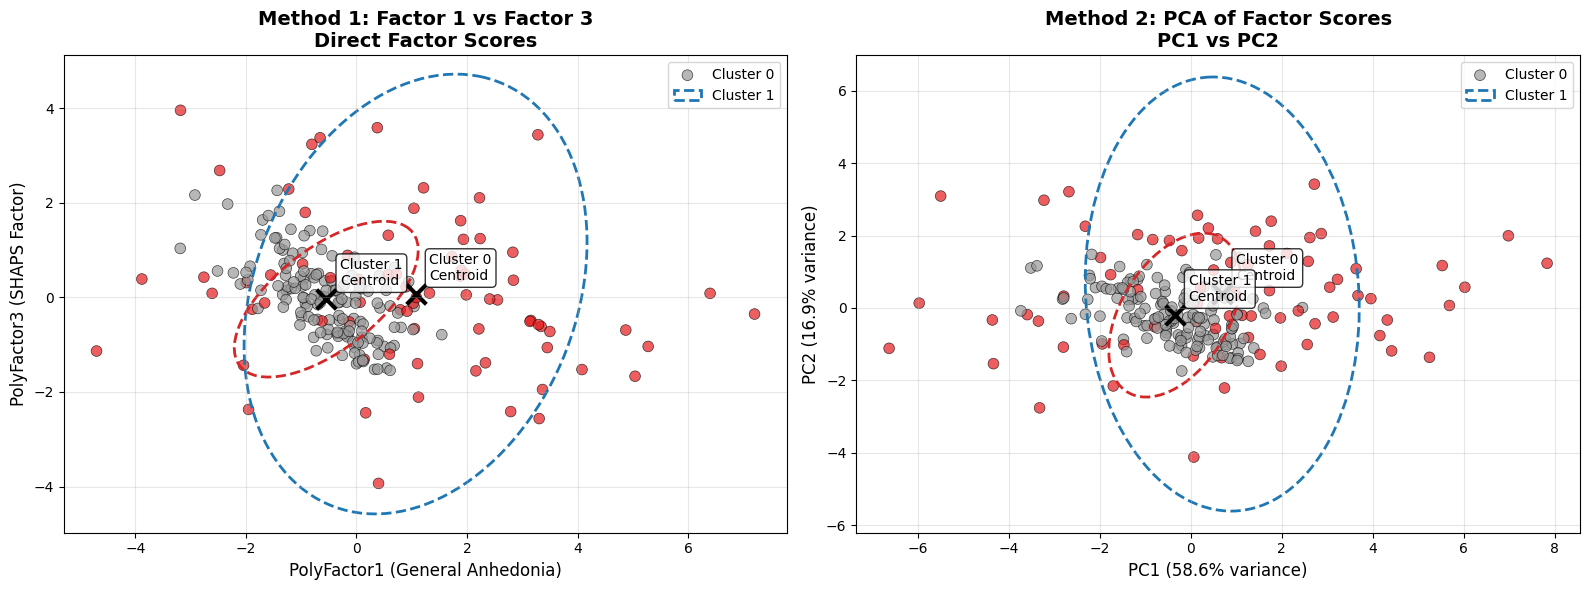


Visualization Summary:
- Method 1 shows separation primarily along Factor 1 (x-axis)
- Method 2 shows optimal 2D representation of all 4 factors
- Both methods should show clear cluster separation
- Cluster 0: n=74
- Cluster 1: n=145


In [37]:
# Cluster Visualizations: Two Approaches
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import numpy as np

# ---------- Helper: confidence ellipse ----------
def draw_confidence_ellipse(x, y, ax, n_std=2.0, edgecolor='black', facecolor='none', linewidth=2, linestyle='--', **kwargs):
    """Draw a covariance confidence ellipse around a cluster."""
    cov = np.cov(x, y)
    evals, evecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*evecs[:, 1][::-1]))
    width, height = 2 * n_std * np.sqrt(evals)
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height, angle=angle,
        edgecolor=edgecolor, facecolor=facecolor,
        linewidth=linewidth, linestyle=linestyle, **kwargs
    )
    ax.add_patch(ellipse)

# Set up the plotting style
plt.style.use('default')
cluster_colors = ['tab:blue', 'tab:red']

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Method 1: Factor 1 vs Factor 3 (Direct factor scores)
print("Method 1: Direct Factor Visualization (PolyFactor1 vs PolyFactor3)")
print("=" * 70)

# Get factor scores and cluster assignments
factor1_scores = factor_scores_poly_df['PolyFactor1']
factor3_scores = factor_scores_poly_df['PolyFactor3']
clusters = factor_scores_poly_df['gmm_cluster']
probabilities = factor_scores_poly_df['max_probability']

# Create scatter plot for Method 1
scatter1 = ax1.scatter(factor1_scores, factor3_scores,
                       c=clusters, cmap='Set1',
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

# Draw confidence ellipses for Method 1
for i, cluster in enumerate([0, 1]):
    mask = (clusters == cluster)
    draw_confidence_ellipse(
        factor1_scores[mask].values, factor3_scores[mask].values,
        ax1, n_std=2.0, edgecolor=cluster_colors[i]
    )

# Add cluster centroids
for cluster in [0, 1]:
    cluster_data = factor_scores_poly_df[factor_scores_poly_df['gmm_cluster'] == cluster]
    centroid_x = cluster_data['PolyFactor1'].mean()
    centroid_y = cluster_data['PolyFactor3'].mean()
    ax1.scatter(centroid_x, centroid_y, c='black', marker='x', s=200, linewidth=3)
    ax1.annotate(f'Cluster {cluster}\nCentroid',
                 xy=(centroid_x, centroid_y), xytext=(10, 10),
                 textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax1.set_xlabel('PolyFactor1 (General Anhedonia)', fontsize=12)
ax1.set_ylabel('PolyFactor3 (SHAPS Factor)', fontsize=12)
ax1.set_title('Method 1: Factor 1 vs Factor 3\nDirect Factor Scores', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(['Cluster 0', 'Cluster 1'], loc='upper right')

# Print separation statistics for Method 1
print(f"Factor 1 separation:")
print(f"  Cluster 0: {factor_scores_poly_df[clusters==0]['PolyFactor1'].mean():.3f} ± {factor_scores_poly_df[clusters==0]['PolyFactor1'].std():.3f}")
print(f"  Cluster 1: {factor_scores_poly_df[clusters==1]['PolyFactor1'].mean():.3f} ± {factor_scores_poly_df[clusters==1]['PolyFactor1'].std():.3f}")
print(f"Factor 3 separation:")
print(f"  Cluster 0: {factor_scores_poly_df[clusters==0]['PolyFactor3'].mean():.3f} ± {factor_scores_poly_df[clusters==0]['PolyFactor3'].std():.3f}")
print(f"  Cluster 1: {factor_scores_poly_df[clusters==1]['PolyFactor3'].mean():.3f} ± {factor_scores_poly_df[clusters==1]['PolyFactor3'].std():.3f}")

# Method 2: PCA of all 4 factor scores
print(f"\nMethod 2: PCA of Factor Scores (PC1 vs PC2)")
print("=" * 50)

# Prepare factor score matrix for PCA
factor_matrix = factor_scores_poly_df[['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']].values

# Apply PCA
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(factor_matrix)

# Create scatter plot for Method 2
scatter2 = ax2.scatter(pca_scores[:, 0], pca_scores[:, 1],
                       c=clusters, cmap='Set1',
                       alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

# Draw confidence ellipses for Method 2
for i, cluster in enumerate([0, 1]):
    mask = (clusters == cluster).values
    draw_confidence_ellipse(
        pca_scores[mask, 0], pca_scores[mask, 1],
        ax2, n_std=2.0, edgecolor=cluster_colors[i]
    )

# Add cluster centroids for PCA
for cluster in [0, 1]:
    cluster_mask = clusters == cluster
    centroid_x = pca_scores[cluster_mask, 0].mean()
    centroid_y = pca_scores[cluster_mask, 1].mean()
    ax2.scatter(centroid_x, centroid_y, c='black', marker='x', s=200, linewidth=3)
    ax2.annotate(f'Cluster {cluster}\nCentroid',
                 xy=(centroid_x, centroid_y), xytext=(10, 10),
                 textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax2.set_title('Method 2: PCA of Factor Scores\nPC1 vs PC2', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(['Cluster 0', 'Cluster 1'], loc='upper right')

# Print PCA information
print(f"PCA Results:")
print(f"  PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"  PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

print(f"\nPCA Component Loadings:")
component_loadings = pd.DataFrame(pca.components_.T,
                                  columns=['PC1', 'PC2'],
                                  index=['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4'])
print(component_loadings.round(3))

# Print PC separation statistics
pc1_cluster0 = pca_scores[clusters==0, 0]
pc1_cluster1 = pca_scores[clusters==1, 0]
pc2_cluster0 = pca_scores[clusters==0, 1]
pc2_cluster1 = pca_scores[clusters==1, 1]

print(f"\nPC separation:")
print(f"  PC1 - Cluster 0: {pc1_cluster0.mean():.3f} ± {pc1_cluster0.std():.3f}")
print(f"  PC1 - Cluster 1: {pc1_cluster1.mean():.3f} ± {pc1_cluster1.std():.3f}")
print(f"  PC2 - Cluster 0: {pc2_cluster0.mean():.3f} ± {pc2_cluster0.std():.3f}")
print(f"  PC2 - Cluster 1: {pc2_cluster1.mean():.3f} ± {pc2_cluster1.std():.3f}")

plt.tight_layout()
plt.show()

# Summary
print(f"\nVisualization Summary:")
print(f"- Method 1 shows separation primarily along Factor 1 (x-axis)")
print(f"- Method 2 shows optimal 2D representation of all 4 factors")
print(f"- Both methods should show clear cluster separation")
print(f"- Cluster 0: n={len(factor_scores_poly_df[clusters==0])}")
print(f"- Cluster 1: n={len(factor_scores_poly_df[clusters==1])}")


In [38]:
# Welch's t-tests for differences between polychoric clusters - FOCUSED ANALYSIS
from scipy import stats
import numpy as np
from statsmodels.stats.multitest import fdrcorrection

print("Welch's T-tests for Polychoric Cluster Differences - FOCUSED ANALYSIS:")
print("=" * 70)

# Calculate total scores for each scale
print("\nCalculating total scale scores...")

# SHAPS Total (already calculated, but ensure it's available)
if 'shaps_total' not in cluster_data_full_poly.columns:
    cluster_data_full_poly['shaps_total'] = cluster_data_full_poly[shaps_items_list].sum(axis=1)

# TEPS Total (all 18 items combined)
teps_all_items = teps_anticipatory + teps_consummatory
cluster_data_full_poly['teps_total'] = cluster_data_full_poly[teps_all_items].mean(axis=1)

# DASS Anhedonia Total
cluster_data_full_poly['dass_anhedonia_total'] = cluster_data_full_poly[dass_anticipatory + dass_consummatory].mean(axis=1)

# Get cluster data AFTER creating new columns
cluster_0_data_poly = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'] == 0]
cluster_1_data_poly = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'] == 1]

# Test differences in total scale scores (WITH FDR correction)
scales_total = {
    'SHAPS_Total': 'shaps_total',
    'TEPS_Total': 'teps_total', 
    'DASS_Anhedonia_Total': 'dass_anhedonia_total'
}

print("\nScale Totals (FDR-corrected for multiple comparisons):")
print("=" * 55)

# Collect all scale results for FDR correction
scale_results = []
for scale_name, column_name in scales_total.items():
    cluster_0_scores = cluster_0_data_poly[column_name]
    cluster_1_scores = cluster_1_data_poly[column_name]
    
    # Welch's t-test (unequal variances)
    t_stat, p_val = stats.ttest_ind(cluster_0_scores, cluster_1_scores, equal_var=False)
    
    # Calculate effect size (Cohen's d)
    pooled_std = np.sqrt(((len(cluster_0_scores) - 1) * cluster_0_scores.var() + 
                         (len(cluster_1_scores) - 1) * cluster_1_scores.var()) / 
                        (len(cluster_0_scores) + len(cluster_1_scores) - 2))
    cohens_d = (cluster_0_scores.mean() - cluster_1_scores.mean()) / pooled_std
    
    scale_results.append({
        'scale': scale_name,
        'cluster_0_mean': cluster_0_scores.mean(),
        'cluster_0_std': cluster_0_scores.std(),
        'cluster_1_mean': cluster_1_scores.mean(),
        'cluster_1_std': cluster_1_scores.std(),
        't_stat': t_stat,
        'p_val': p_val,
        'cohens_d': cohens_d
    })

# Apply FDR correction to scale p-values
scale_p_values = [result['p_val'] for result in scale_results]
scale_fdr_rejected, scale_fdr_p_corrected = fdrcorrection(scale_p_values, alpha=0.05, method='indep')

# Display scale results with FDR correction
for i, result in enumerate(scale_results):
    print(f"\n{result['scale']}:")
    print(f"  Cluster 0: {result['cluster_0_mean']:.3f} ± {result['cluster_0_std']:.3f} (n={len(cluster_0_data_poly)})")
    print(f"  Cluster 1: {result['cluster_1_mean']:.3f} ± {result['cluster_1_std']:.3f} (n={len(cluster_1_data_poly)})")
    print(f"  Welch's t = {result['t_stat']:.3f}, p = {result['p_val']:.4f}, Cohen's d = {result['cohens_d']:.3f}")
    
    # Significance indicators (both uncorrected and FDR-corrected)
    if result['p_val'] < 0.001:
        sig_uncorr = "***"
    elif result['p_val'] < 0.01:
        sig_uncorr = "**"
    elif result['p_val'] < 0.05:
        sig_uncorr = "*"
    else:
        sig_uncorr = "ns"
    
    # FDR-corrected significance
    scale_fdr_sig = "significant" if scale_fdr_rejected[i] else "ns"
    
    print(f"  Uncorrected: {sig_uncorr}, FDR-corrected: {scale_fdr_sig} (q = {scale_fdr_p_corrected[i]:.4f})")

# Test differences in factor scores (with FDR correction)
factor_0_data_poly = factor_scores_poly_df[factor_scores_poly_df['gmm_cluster'] == 0]
factor_1_data_poly = factor_scores_poly_df[factor_scores_poly_df['gmm_cluster'] == 1]

print(f"\nPolychoric Factor Scores (FDR-corrected):")
print("=" * 45)

# Collect all p-values for FDR correction
factor_names = ['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']
factor_results = []

for factor in factor_names:
    cluster_0_factor = factor_0_data_poly[factor]
    cluster_1_factor = factor_1_data_poly[factor]
    
    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(cluster_0_factor, cluster_1_factor, equal_var=False)
    
    # Calculate Cohen's d
    pooled_std = np.sqrt(((len(cluster_0_factor) - 1) * cluster_0_factor.var() + 
                         (len(cluster_1_factor) - 1) * cluster_1_factor.var()) / 
                        (len(cluster_0_factor) + len(cluster_1_factor) - 2))
    cohens_d = (cluster_0_factor.mean() - cluster_1_factor.mean()) / pooled_std
    
    factor_results.append({
        'factor': factor,
        'cluster_0_mean': cluster_0_factor.mean(),
        'cluster_0_std': cluster_0_factor.std(),
        'cluster_1_mean': cluster_1_factor.mean(),
        'cluster_1_std': cluster_1_factor.std(),
        't_stat': t_stat,
        'p_val': p_val,
        'cohens_d': cohens_d
    })

# Apply FDR correction to factor p-values
factor_p_values = [result['p_val'] for result in factor_results]
factor_fdr_rejected, factor_fdr_p_corrected = fdrcorrection(factor_p_values, alpha=0.05, method='indep')

# Display factor results with FDR correction
for i, result in enumerate(factor_results):
    print(f"\n{result['factor']}:")
    print(f"  Cluster 0: {result['cluster_0_mean']:.3f} ± {result['cluster_0_std']:.3f}")
    print(f"  Cluster 1: {result['cluster_1_mean']:.3f} ± {result['cluster_1_std']:.3f}")
    print(f"  Welch's t = {result['t_stat']:.3f}, p = {result['p_val']:.4f}, Cohen's d = {result['cohens_d']:.3f}")
    
    # Significance indicators (both uncorrected and FDR-corrected)
    if result['p_val'] < 0.001:
        sig_uncorr = "***"
    elif result['p_val'] < 0.01:
        sig_uncorr = "**"
    elif result['p_val'] < 0.05:
        sig_uncorr = "*"
    else:
        sig_uncorr = "ns"
    
    # FDR-corrected significance
    factor_fdr_sig = "significant" if factor_fdr_rejected[i] else "ns"
    
    print(f"  Uncorrected: {sig_uncorr}, FDR-corrected: {factor_fdr_sig} (q = {factor_fdr_p_corrected[i]:.4f})")

print(f"\nEffect Size Interpretation:")
print("Cohen's d: 0.2 = small, 0.5 = medium, 0.8 = large")
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print(f"\nMultiple Comparison Correction:")
print("- Scale tests: FDR correction applied to 3 comparisons (SHAPS, TEPS, DASS)")
print("- Factor tests: FDR correction applied to 4 comparisons (PolyFactor1-4)")
print("- Separate FDR corrections for scales vs factors (different domains)")

Welch's T-tests for Polychoric Cluster Differences - FOCUSED ANALYSIS:

Calculating total scale scores...

Scale Totals (FDR-corrected for multiple comparisons):

SHAPS_Total:
  Cluster 0: 3.351 ± 3.067 (n=74)
  Cluster 1: 0.145 ± 0.372 (n=145)
  Welch's t = 8.959, p = 0.0000, Cohen's d = 1.777
  Uncorrected: ***, FDR-corrected: significant (q = 0.0000)

TEPS_Total:
  Cluster 0: 3.075 ± 0.689 (n=74)
  Cluster 1: 2.358 ± 0.499 (n=145)
  Welch's t = 7.956, p = 0.0000, Cohen's d = 1.258
  Uncorrected: ***, FDR-corrected: significant (q = 0.0000)

DASS_Anhedonia_Total:
  Cluster 0: 2.151 ± 0.922 (n=74)
  Cluster 1: 1.189 ± 0.358 (n=145)
  Welch's t = 8.652, p = 0.0000, Cohen's d = 1.580
  Uncorrected: ***, FDR-corrected: significant (q = 0.0000)

Polychoric Factor Scores (FDR-corrected):

PolyFactor1:
  Cluster 0: 1.069 ± 2.326
  Cluster 1: -0.546 ± 0.824
  Welch's t = 5.791, p = 0.0000, Cohen's d = 1.072
  Uncorrected: ***, FDR-corrected: significant (q = 0.0000)

PolyFactor2:
  Cluster 0

/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2103006086.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score',
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2103006086.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score',
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2103006086.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score',


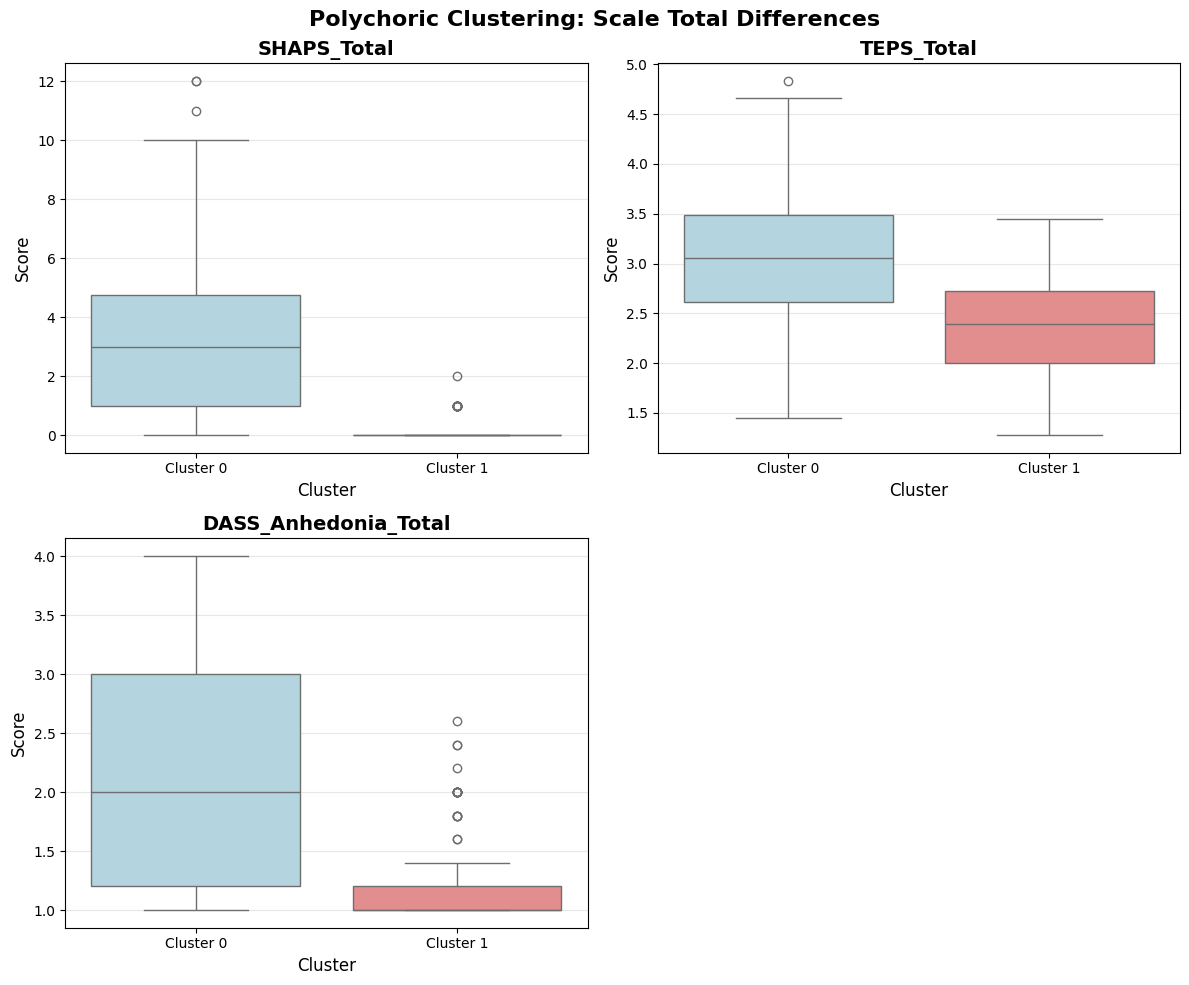

/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2103006086.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score',
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2103006086.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score',
/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2103006086.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=measure_data, x='Cluster', y='Score',
/var/folders/n7/g8bq81dn5879t8l

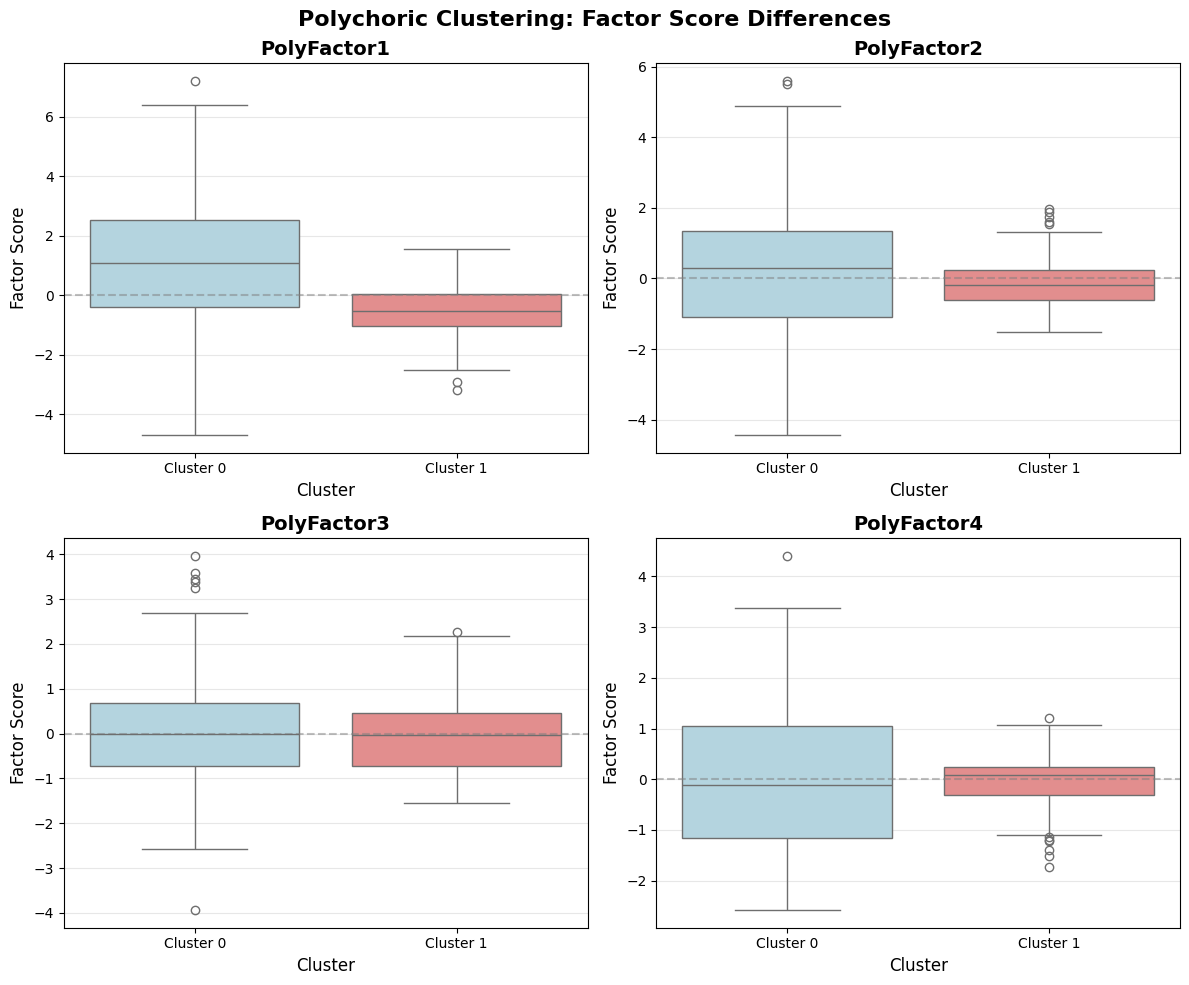

Box plots generated for:
- Scale total differences between polychoric clusters
- Factor score differences between polychoric clusters

Focused on:
- SHAPS Total (sum of all 14 items)
- TEPS Total (mean of all 18 items)
- DASS Anhedonia Total (mean of 5 anhedonia items)
- All 4 polychoric factors


In [39]:
# Box plots for polychoric cluster differences - FOCUSED ANALYSIS
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
plt.style.use('default')
sns.set_palette("Set2")

# Prepare data for plotting
plot_data_poly = []

# Add scale totals (matching the focused analysis)
scales_total = {
    'SHAPS_Total': 'shaps_total',
    'TEPS_Total': 'teps_total',
    'DASS_Anhedonia_Total': 'dass_anhedonia_total'
}

for scale_name, column_name in scales_total.items():
    for cluster in [0, 1]:
        cluster_subset = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'] == cluster]
        scale_scores = cluster_subset[column_name]
        for score in scale_scores:
            plot_data_poly.append({
                'Measure': scale_name,
                'Cluster': f'Cluster {cluster}',
                'Score': score,
                'Type': 'Scale_Total'
            })

# Add factor scores
for factor_col in ['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']:
    for cluster in [0, 1]:
        factor_subset = factor_scores_poly_df[factor_scores_poly_df['gmm_cluster'] == cluster]
        for score in factor_subset[factor_col]:
            plot_data_poly.append({
                'Measure': factor_col,
                'Cluster': f'Cluster {cluster}',
                'Score': score,
                'Type': 'Factor'
            })

# Convert to DataFrame
plot_df_poly = pd.DataFrame(plot_data_poly)

# Create box plots for scale totals
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Scale total measures
scale_measures = ['SHAPS_Total', 'TEPS_Total', 'DASS_Anhedonia_Total']
for i, measure in enumerate(scale_measures):
    measure_data = plot_df_poly[plot_df_poly['Measure'] == measure]
    sns.boxplot(data=measure_data, x='Cluster', y='Score', 
                palette=['lightblue', 'lightcoral'], ax=axes[i])
    axes[i].set_title(f'{measure}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=12)
    axes[i].set_ylabel('Score', fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)

# Remove empty subplot
axes[3].remove()

plt.suptitle('Polychoric Clustering: Scale Total Differences', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Create box plots for factors
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Factor measures
factor_measures = ['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']
for i, measure in enumerate(factor_measures):
    measure_data = plot_df_poly[plot_df_poly['Measure'] == measure]
    sns.boxplot(data=measure_data, x='Cluster', y='Score', 
                palette=['lightblue', 'lightcoral'], ax=axes[i])
    axes[i].set_title(f'{measure}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=12)
    axes[i].set_ylabel('Factor Score', fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Add horizontal line at zero for factor scores
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Polychoric Clustering: Factor Score Differences', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Box plots generated for:")
print("- Scale total differences between polychoric clusters")
print("- Factor score differences between polychoric clusters")
print("\nFocused on:")
print("- SHAPS Total (sum of all 14 items)")
print("- TEPS Total (mean of all 18 items)")  
print("- DASS Anhedonia Total (mean of 5 anhedonia items)")
print("- All 4 polychoric factors")

In [40]:
# Load pre-computed polychoric clusters + factor scores (no re-running GMM)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

poly_clusters = pd.read_csv('NEW_anhedonia_polychoric_gmm_clusters.csv')

# Compute scale totals from item-level dataframes already in memory
dass_items_sub = dass_items[dass_items['subjectkey'].isin(poly_clusters['subjectkey'])].copy()
dass_items_sub['dass_anhedonia_total'] = dass_items_sub[dass_anticipatory + dass_consummatory].sum(axis=1)

shaps_items_sub = shaps_items[shaps_items['subjectkey'].isin(poly_clusters['subjectkey'])].copy()
shaps_items_sub['shaps_total'] = shaps_items_sub[shaps_items_list].sum(axis=1)


teps_items_sub = teps_items[teps_items['subjectkey'].isin(poly_clusters['subjectkey'])].copy()
teps_items_sub['teps_total'] = (7 - teps_items_sub.iloc[:, 1:]).sum(axis=1)


cluster_data_full_poly = poly_clusters.merge(
    shaps_items_sub[['subjectkey', 'shaps_total']], on='subjectkey'
).merge(
    teps_items_sub[['subjectkey', 'teps_total']], on='subjectkey'
).merge(
    dass_items_sub[['subjectkey', 'dass_anhedonia_total']], on='subjectkey'
)

# Style
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

CLUSTER_COLORS = {
    'High Anhedonia': "#D65A7A",
    'Low Anhedonia': "#3AAFB9"
}
CLUSTER_LABEL_MAP = {0: 'High Anhedonia', 1: 'Low Anhedonia'}
cluster_order = ['Low Anhedonia', 'High Anhedonia']

scales_total = {
    'SHAPS_Total': 'shaps_total',
    'TEPS_Total': 'teps_total',
    'DASS_Anhedonia_Total': 'dass_anhedonia_total'
}

# Build long-form data
plot_data = []
for scale_name, column_name in scales_total.items():
    for cluster in [0, 1]:
        subset = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'] == cluster]
        for score in subset[column_name]:
            plot_data.append({'Measure': scale_name, 'Cluster': CLUSTER_LABEL_MAP[cluster], 'Score': score})

plot_df = pd.DataFrame(plot_data)



def add_pvalue_annotation(ax, p_val):
    """Place a clean p-value bracket above the two violins."""
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin
    
    bracket_y = ymax + y_range * 0.02   # just above the violin top
    tick_h    = y_range * 0.02          # small vertical ticks
    
    # Draw bracket: left tick, horizontal bar, right tick
    ax.plot([0, 0, 1, 1],
            [bracket_y, bracket_y + tick_h, bracket_y + tick_h, bracket_y],
            lw=1.2, color='black', clip_on=False)
    
    if p_val < 0.001:
        label = 'p < 0.001'
    elif p_val < 0.01:
        label = f'p = {p_val:.3f}'
    else:
        label = f'p = {p_val:.2f}'
    
    # FIX: Removed the transform argument so it uses data coordinates
    ax.text(0.5, bracket_y + tick_h * 1.5, label,
            ha='center', va='bottom', fontsize=10)
    
    # Expand ylim to show the annotation
    ax.set_ylim(top=ymax + y_range * 0.14)

# Plot
# plot_names = ['SHAPS Total', 'TEPS Total', 'DASS Anhedonia Total']
# fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# for i, (measure, column_name) in enumerate(scales_total.items()):
#     measure_data = plot_df[plot_df['Measure'] == measure]
    
#     # 1. Draw the Violin Plot
#     sns.violinplot(data=measure_data, x='Cluster', y='Score',
#                    order=cluster_order,
#                    palette=CLUSTER_COLORS,
#                    inner='box',      # Keeps the mini-boxplot inside
#                    linewidth=1.2,
#                    alpha=0.75,        # Increased transparency to let points show through
#                    ax=axes[i])
    
#     # 2. Add the Strip Plot
#     sns.stripplot(data=measure_data, x='Cluster', y='Score',
#                   order=cluster_order,
#                   color='black',      # Dark points for contrast
#                   jitter=True,        # Spreads points out horizontally
#                   size=3,             # Smaller dots to avoid clutter
#                   alpha=0.3,          # Transparency to handle overlapping points
#                   ax=axes[i])

#     axes[i].set_title(plot_names[i], fontsize=13, fontweight='bold')
#     axes[i].set_xlabel('Cluster', fontsize=11)
#     axes[i].set_ylabel('Score', fontsize=11)

#     # Compute p-value
#     low  = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'].map(CLUSTER_LABEL_MAP) == 'Low Anhedonia'][column_name]
#     high = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'].map(CLUSTER_LABEL_MAP) == 'High Anhedonia'][column_name]
#     _, p = mannwhitneyu(low, high, alternative='two-sided')

#     add_pvalue_annotation(axes[i], p)

# plt.suptitle('Anhedonia Clusters: Scale Total Differences', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig('anhedonia_clusters_scale_totals.png', dpi=600, bbox_inches='tight')
# plt.show()

/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/proghani/.pyenv/versions/3.12.9/lib/python3.12/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


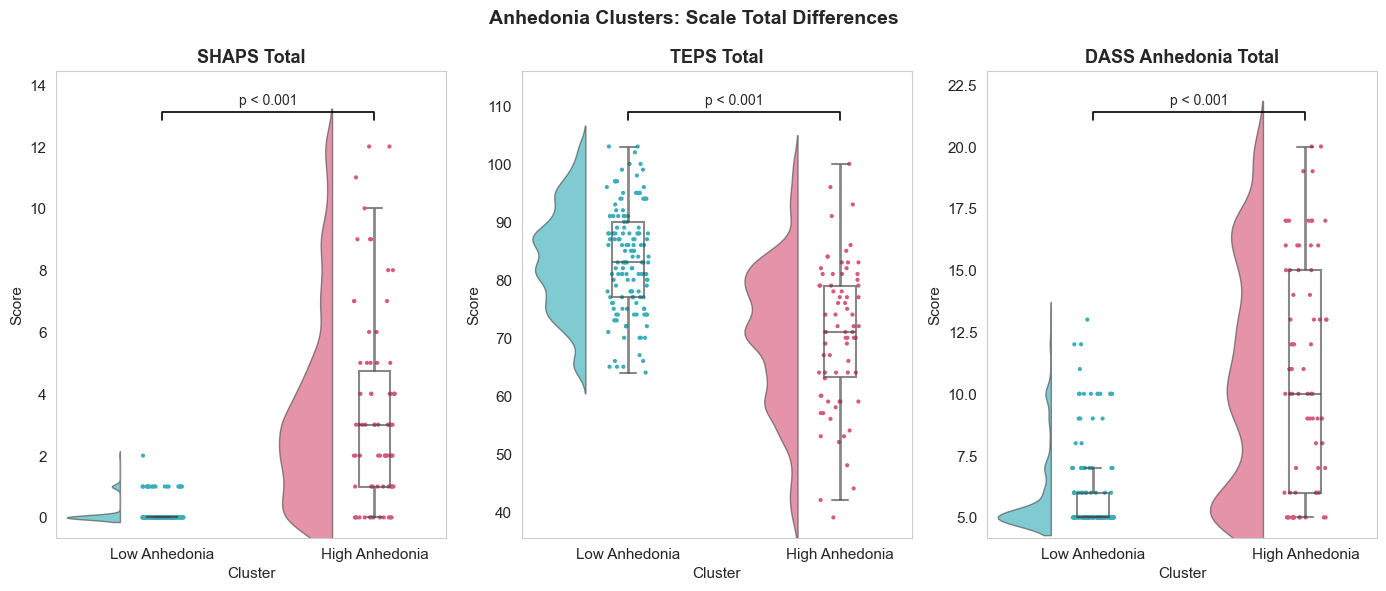

In [41]:
import ptitprince as pt

# Build long-form data
plot_data = []
for scale_name, column_name in scales_total.items():
    for cluster in [0, 1]:
        subset = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'] == cluster]
        for score in subset[column_name]:
            plot_data.append({'Measure': scale_name, 'Cluster': CLUSTER_LABEL_MAP[cluster], 'Score': score})

plot_df = pd.DataFrame(plot_data)

# Force category order so every RainCloud layer colors consistently
plot_df['Cluster'] = pd.Categorical(
    plot_df['Cluster'], categories=cluster_order, ordered=True
)

plot_names = ['SHAPS Total', 'TEPS Total', 'DASS Anhedonia Total']
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

for i, (measure, column_name) in enumerate(scales_total.items()):
    measure_data = plot_df[plot_df['Measure'] == measure]

    pt.RainCloud(
        data=measure_data, x='Cluster', y='Score',
        order=cluster_order,
        palette=[CLUSTER_COLORS[c] for c in cluster_order],
        ax=axes[i],
        orient='v',
        width_viol=0.5,
        width_box=0.15,
        point_size=3,
        alpha=0.65,
        cut=2,
        scale='width',          # <-- normalize each cloud to equal max width
        box_showfliers=False,
        box_linewidth=1.5,
    )


    axes[i].grid(False)
    axes[i].set_title(plot_names[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=11)
    axes[i].set_ylabel('Score', fontsize=11)

    # Compute p-value
    low  = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'].map(CLUSTER_LABEL_MAP) == 'Low Anhedonia'][column_name]
    high = cluster_data_full_poly[cluster_data_full_poly['gmm_cluster'].map(CLUSTER_LABEL_MAP) == 'High Anhedonia'][column_name]
    _, p = mannwhitneyu(low, high, alternative='two-sided')

    add_pvalue_annotation(axes[i], p)

plt.suptitle('Anhedonia Clusters: Scale Total Differences', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('anhedonia_clusters_scale_totals.png', dpi=600, bbox_inches='tight')
plt.show()


In [42]:
# Import demographics data and combine with cluster results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importing Demographics Data and Combining with Cluster Results")
print("=" * 65)

# Import demographics data
demos_df = pd.read_excel('/Users/proghani/Documents/personal/local_thesis_proj/TCP_thesis_project/phenotype/demos_payman.xls', header=1)
print(f"Demographics data loaded: {demos_df.shape[0]} subjects, {demos_df.shape[1]} variables")

# Merge cluster results with demographics
cluster_demo_df = demos_df.merge(factor_scores_poly_df[['subjectkey', 'gmm_cluster']], 
                                on='subjectkey', 
                                how='inner')

print(f"After merging with cluster results: {cluster_demo_df.shape[0]} subjects")
print(f"Cluster 0: n={len(cluster_demo_df[cluster_demo_df['gmm_cluster'] == 0])}")
print(f"Cluster 1: n={len(cluster_demo_df[cluster_demo_df['gmm_cluster'] == 1])}")

# Create mapping from abbreviations to full names (from proposal_defence.ipynb)
label_mapping = {
    '999': 'None',
    'MDD': 'Major Depressive Disorder',
    'BP1': 'Bipolar Disorder Type 1',
    'PTSD': 'Post-Traumatic Stress Disorder',
    'GAD': 'Generalized Anxiety Disorder',
    'Dysthymia': 'Dysthymia',
    'SUD': 'Substance Use Disorder',
    'SAD': 'Social Anxiety Disorder',
    'SZA': 'Schizoaffective Disorder',
    'SZ': 'Schizophrenia',
    'BP2': 'Bipolar Disorder Type 2',
    'Other Anxiety': 'Other Anxiety',
    'ADHD': 'Attention-Deficit/Hyperactivity Disorder',
    'Other Mood Dis': 'Other Mood Disorder',
    'OCD': 'Obsessive Compulsive Disorder',
    'ED': 'Eating Disorder'
}

# Clean diagnosis codes
cluster_demo_df['Primary_Dx_Payman'] = cluster_demo_df['Primary_Dx_Payman'].astype(str).str.strip()

# Show diagnosis distribution within each cluster
print(f"\nDiagnosis Distribution by Cluster:")
print("=" * 40)

for cluster in [0, 1]:
    cluster_subset = cluster_demo_df[cluster_demo_df['gmm_cluster'] == cluster]
    dx_counts = cluster_subset['Primary_Dx_Payman'].value_counts()
    
    print(f"\nCluster {cluster} (n={len(cluster_subset)}):")
    print("-" * 25)
    for dx, count in dx_counts.head(10).items():  # Show top 10
        full_name = label_mapping.get(dx, dx)
        percentage = (count / len(cluster_subset)) * 100
        print(f"  {full_name}: {count} ({percentage:.1f}%)")

# Create crosstab for visualization
crosstab = pd.crosstab(cluster_demo_df['Primary_Dx_Payman'], cluster_demo_df['gmm_cluster'])
crosstab = crosstab.reindex(columns=[0, 1], fill_value=0)

# Sort by total count descending
crosstab = crosstab.loc[crosstab.sum(axis=1).sort_values(ascending=False).index]

# Only show diagnoses with at least 3 total cases for clarity
crosstab_filtered = crosstab[crosstab.sum(axis=1) >= 3]

# Replace labels with full names
full_labels = [label_mapping.get(label, label) for label in crosstab_filtered.index]

print(f"\nCrosstab Results (diagnoses with ≥3 cases):")
print(crosstab_filtered)

Importing Demographics Data and Combining with Cluster Results
Demographics data loaded: 245 subjects, 118 variables
After merging with cluster results: 219 subjects
Cluster 0: n=74
Cluster 1: n=145

Diagnosis Distribution by Cluster:

Cluster 0 (n=74):
-------------------------
  Major Depressive Disorder: 16 (21.6%)
  None: 16 (21.6%)
  Bipolar Disorder Type 1: 6 (8.1%)
  Post-Traumatic Stress Disorder: 6 (8.1%)
  Bipolar Disorder Type 2: 5 (6.8%)
  Generalized Anxiety Disorder: 5 (6.8%)
  Social Anxiety Disorder: 4 (5.4%)
  Dysthymia: 4 (5.4%)
  Other Anxiety: 3 (4.1%)
  Schizoaffective Disorder: 2 (2.7%)

Cluster 1 (n=145):
-------------------------
  None: 73 (50.3%)
  Major Depressive Disorder: 17 (11.7%)
  Generalized Anxiety Disorder: 10 (6.9%)
  Post-Traumatic Stress Disorder: 8 (5.5%)
  Bipolar Disorder Type 1: 7 (4.8%)
  Substance Use Disorder: 7 (4.8%)
  Dysthymia: 5 (3.4%)
  Social Anxiety Disorder: 4 (2.8%)
  Attention-Deficit/Hyperactivity Disorder: 3 (2.1%)
  Other Anxi

In [43]:
# Age and Gender Analysis
print("\nAge and Gender Analysis")
print("=" * 30)

# Convert age from months to years
cluster_demo_df['age_years'] = cluster_demo_df['interview_age'] / 12

# Overall sample statistics
print("ENTIRE SAMPLE:")
print(f"Average age: {cluster_demo_df['age_years'].mean():.2f} years (SD = {cluster_demo_df['age_years'].std():.2f})")
print(f"Age range: {cluster_demo_df['age_years'].min():.1f} - {cluster_demo_df['age_years'].max():.1f} years")

# Gender breakdown for entire sample
gender_counts_total = cluster_demo_df['sex'].value_counts()
gender_pct_total = cluster_demo_df['sex'].value_counts(normalize=True) * 100
print("\nGender breakdown:")
for gender in gender_counts_total.index:
    print(f"  {gender}: {gender_counts_total[gender]} ({gender_pct_total[gender]:.1f}%)")

print(f"\nTotal sample size: {len(cluster_demo_df)}")


Age and Gender Analysis
ENTIRE SAMPLE:
Average age: 34.15 years (SD = 13.48)
Age range: 18.1 - 65.0 years

Gender breakdown:
  F: 127 (58.0%)
  M: 89 (40.6%)
  O: 3 (1.4%)

Total sample size: 219


/var/folders/n7/g8bq81dn5879t8lq7djjjst40000gn/T/ipykernel_23262/2734823853.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cluster_demo_df['age_years'] = cluster_demo_df['interview_age'] / 12


In [44]:
# Add primary diagnosis 999 count to the analysis
dx_999_count = len(cluster_demo_df[cluster_demo_df['Primary_Dx_Payman'] == '999'])
dx_999_pct = (dx_999_count / len(cluster_demo_df)) * 100
print(f"Primary diagnosis '999' (None): {dx_999_count} ({dx_999_pct:.1f}%)")

Primary diagnosis '999' (None): 89 (40.6%)


In [45]:
# By cluster analysis
print("\n" + "="*50)
print("BY CLUSTER ANALYSIS:")
print("="*50)

for cluster in [0, 1]:
    cluster_data = cluster_demo_df[cluster_demo_df['gmm_cluster'] == cluster]
    
    print(f"\nCLUSTER {cluster} (n={len(cluster_data)}):")
    print(f"Average age: {cluster_data['age_years'].mean():.2f} years (SD = {cluster_data['age_years'].std():.2f})")
    print(f"Age range: {cluster_data['age_years'].min():.1f} - {cluster_data['age_years'].max():.1f} years")
    
    # Gender breakdown by cluster
    gender_counts = cluster_data['sex'].value_counts()
    gender_pct = cluster_data['sex'].value_counts(normalize=True) * 100
    print("Gender breakdown:")
    for gender in gender_counts.index:
        print(f"  {gender}: {gender_counts[gender]} ({gender_pct[gender]:.1f}%)")


BY CLUSTER ANALYSIS:

CLUSTER 0 (n=74):
Average age: 36.52 years (SD = 15.30)
Age range: 18.2 - 64.5 years
Gender breakdown:
  F: 48 (64.9%)
  M: 24 (32.4%)
  O: 2 (2.7%)

CLUSTER 1 (n=145):
Average age: 32.94 years (SD = 12.32)
Age range: 18.1 - 65.0 years
Gender breakdown:
  F: 79 (54.5%)
  M: 65 (44.8%)
  O: 1 (0.7%)


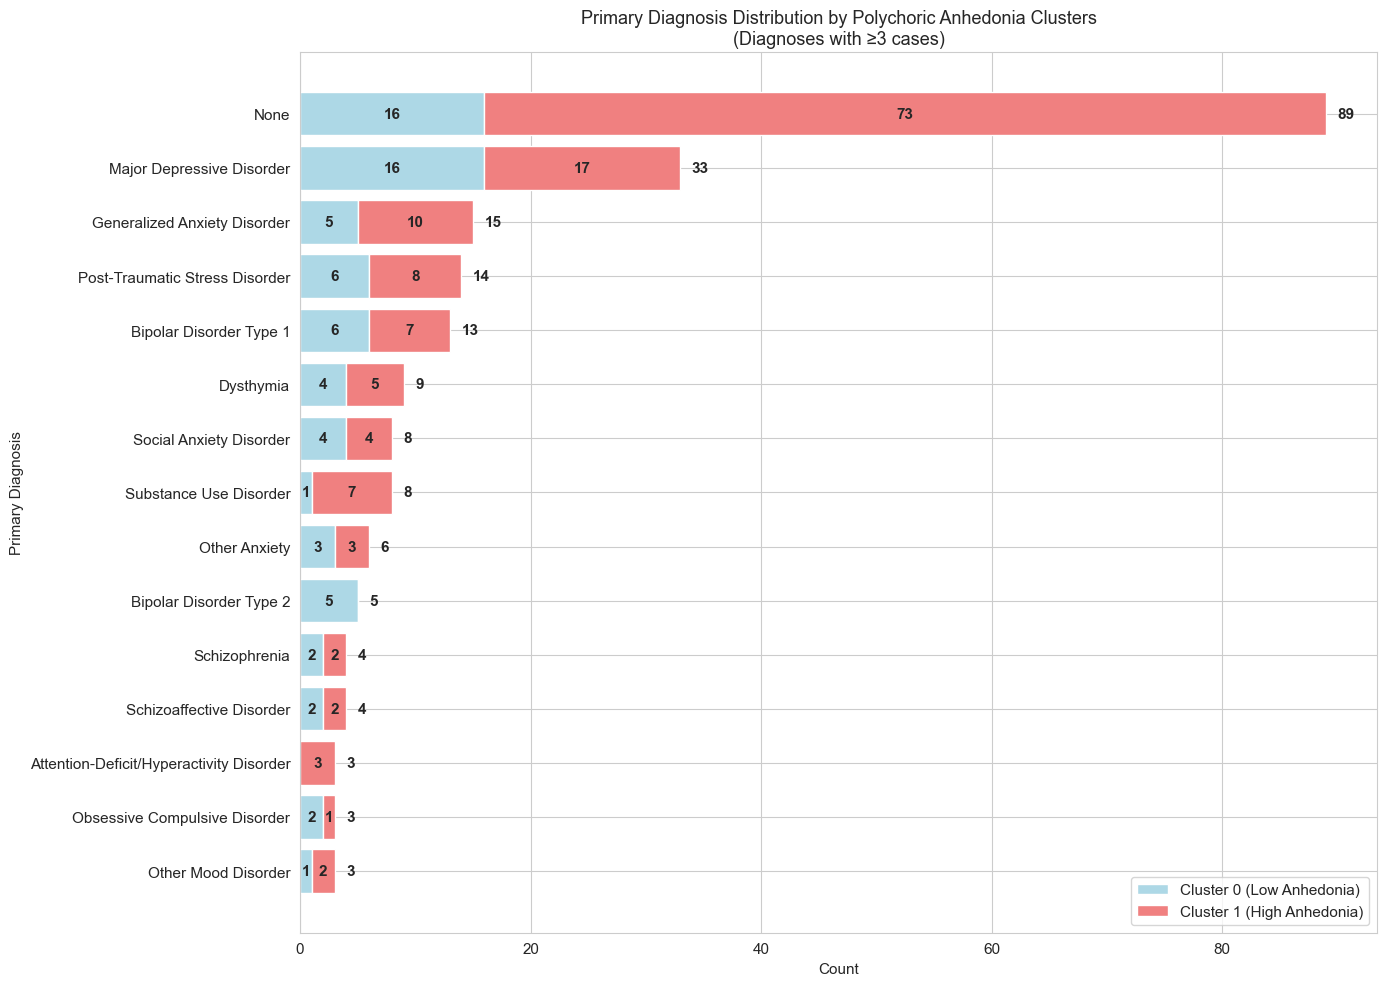


Percentage Distribution Within Each Diagnosis:
(What percentage of each diagnosis falls into each cluster)

None (n=89):
  Cluster 0: 18.0%
  Cluster 1: 82.0%

Major Depressive Disorder (n=33):
  Cluster 0: 48.5%
  Cluster 1: 51.5%

Generalized Anxiety Disorder (n=15):
  Cluster 0: 33.3%
  Cluster 1: 66.7%

Post-Traumatic Stress Disorder (n=14):
  Cluster 0: 42.9%
  Cluster 1: 57.1%

Bipolar Disorder Type 1 (n=13):
  Cluster 0: 46.2%
  Cluster 1: 53.8%

Dysthymia (n=9):
  Cluster 0: 44.4%
  Cluster 1: 55.6%

Social Anxiety Disorder (n=8):
  Cluster 0: 50.0%
  Cluster 1: 50.0%

Substance Use Disorder (n=8):
  Cluster 0: 12.5%
  Cluster 1: 87.5%

Other Anxiety (n=6):
  Cluster 0: 50.0%
  Cluster 1: 50.0%

Bipolar Disorder Type 2 (n=5):
  Cluster 0: 100.0%
  Cluster 1: 0.0%

Schizophrenia (n=4):
  Cluster 0: 50.0%
  Cluster 1: 50.0%

Schizoaffective Disorder (n=4):
  Cluster 0: 50.0%
  Cluster 1: 50.0%

Attention-Deficit/Hyperactivity Disorder (n=3):
  Cluster 0: 0.0%
  Cluster 1: 100.0%

In [46]:
# Visualize diagnosis distribution by cluster
plt.figure(figsize=(14, 10))

# Create stacked horizontal bar chart
mid_dark_blue = "#2E5AAC"

bars_cluster0 = plt.barh(range(len(crosstab_filtered)), crosstab_filtered[0], 
                        label='Cluster 0 (Low Anhedonia)', color='lightblue')
bars_cluster1 = plt.barh(range(len(crosstab_filtered)), crosstab_filtered[1], 
                        left=crosstab_filtered[0], label='Cluster 1 (High Anhedonia)', 
                        color='lightcoral')

plt.yticks(range(len(crosstab_filtered)), full_labels)

# Add count labels on bars
for i, (cluster0, cluster1) in enumerate(zip(crosstab_filtered[0], crosstab_filtered[1])):
    total = cluster0 + cluster1
    
    # Label for cluster 0
    if cluster0 > 0:
        plt.text(cluster0/2, i, str(cluster0), va='center', ha='center', fontweight='bold')
    
    # Label for cluster 1
    if cluster1 > 0:
        plt.text(cluster0 + cluster1/2, i, str(cluster1), va='center', ha='center', fontweight='bold')
    
    # Total count at the end
    plt.text(total + 1, i, str(total), va='center', ha='left', fontweight='bold')

plt.xlabel('Count')
plt.ylabel('Primary Diagnosis')
plt.title('Primary Diagnosis Distribution by Polychoric Anhedonia Clusters\n(Diagnoses with ≥3 cases)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Calculate and display percentages within each diagnosis
print(f"\nPercentage Distribution Within Each Diagnosis:")
print("=" * 50)
print("(What percentage of each diagnosis falls into each cluster)")
print()

crosstab_pct = crosstab_filtered.div(crosstab_filtered.sum(axis=1), axis=0) * 100

for i, dx in enumerate(crosstab_filtered.index):
    full_name = label_mapping.get(dx, dx)
    total_n = crosstab_filtered.loc[dx].sum()
    cluster0_pct = crosstab_pct.loc[dx, 0]
    cluster1_pct = crosstab_pct.loc[dx, 1]
    
    print(f"{full_name} (n={total_n}):")
    print(f"  Cluster 0: {cluster0_pct:.1f}%")
    print(f"  Cluster 1: {cluster1_pct:.1f}%")
    print()

# Statistical test for association
from scipy.stats import chi2_contingency

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(crosstab_filtered)

print(f"Statistical Test for Association:")
print("=" * 40)
print(f"Chi-square test: χ² = {chi2:.3f}, df = {dof}, p = {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant association between diagnosis and cluster membership")
else:
    print("Result: No significant association between diagnosis and cluster membership")
    
print(f"\nNote: Test includes diagnoses with ≥3 cases (n={len(crosstab_filtered)} diagnoses)")

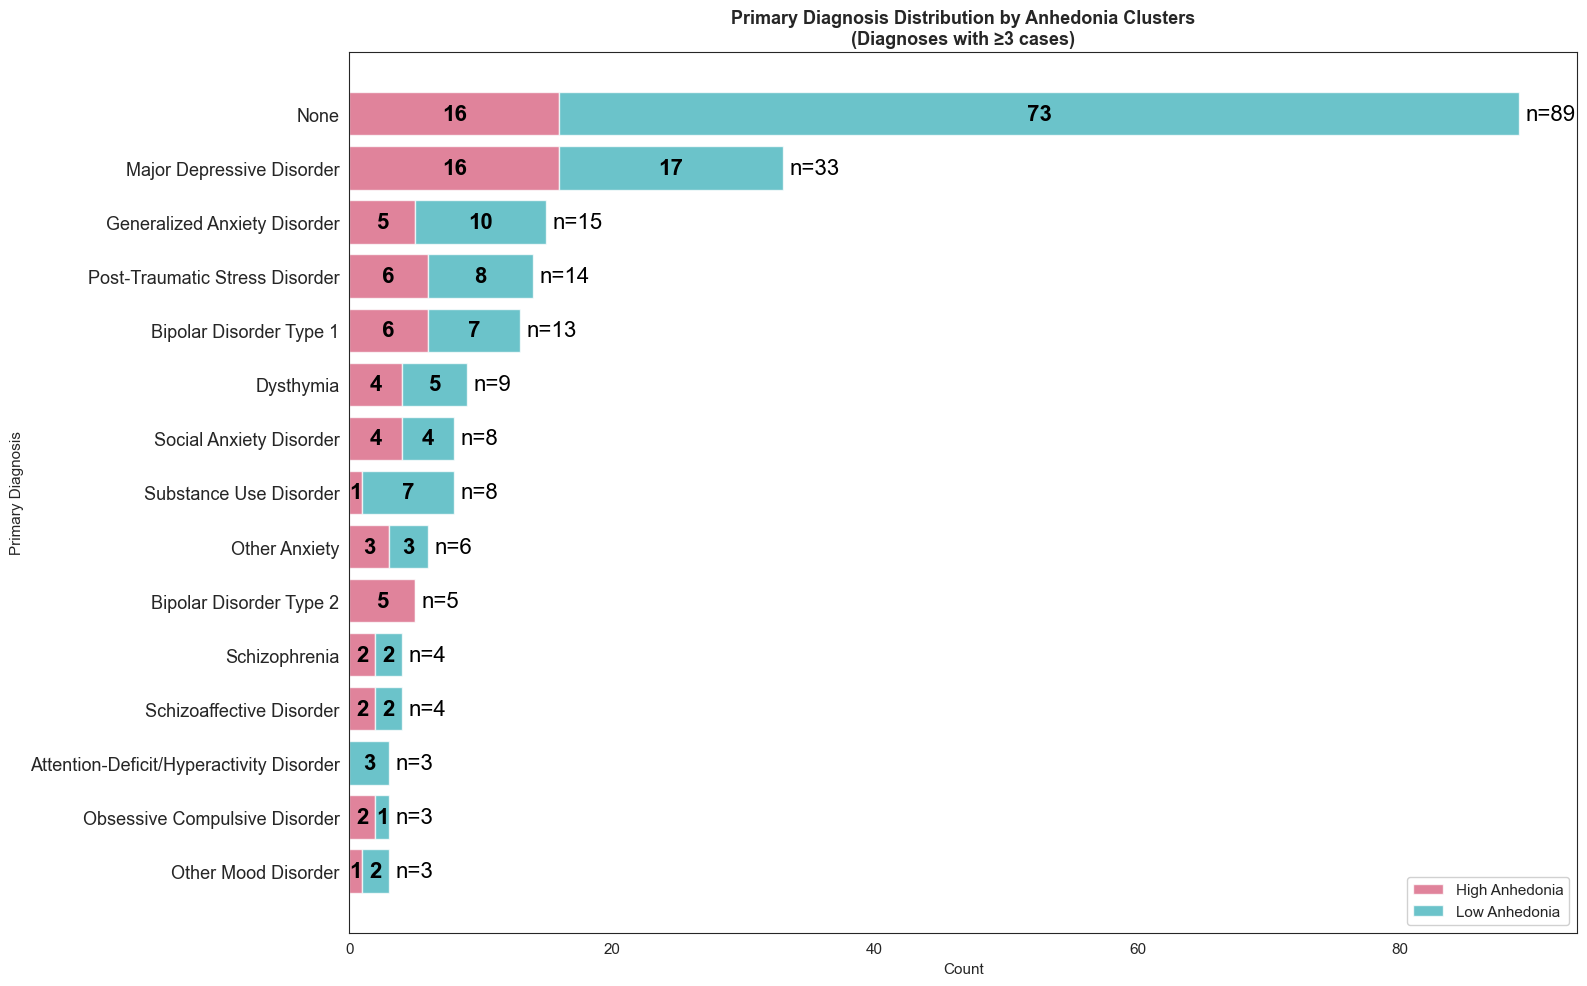

In [56]:
# Visualize diagnosis distribution by cluster
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

CLUSTER_COLORS = {
    'High Anhedonia': "#D65A7A",
    'Low Anhedonia': "#3AAFB9"
}

fig, ax = plt.subplots(figsize=(16, 10))

# cluster 0 = High Anhedonia, cluster 1 = Low Anhedonia
bars_high = ax.barh(range(len(crosstab_filtered)), crosstab_filtered[0],
                    label='High Anhedonia', color=CLUSTER_COLORS['High Anhedonia'], alpha=0.75)
bars_low  = ax.barh(range(len(crosstab_filtered)), crosstab_filtered[1],
                    left=crosstab_filtered[0],
                    label='Low Anhedonia', color=CLUSTER_COLORS['Low Anhedonia'], alpha=0.75)

ax.set_yticks(range(len(crosstab_filtered)))
ax.set_yticklabels(full_labels, fontsize=13)

# Count labels inside bars
for i, (c0, c1) in enumerate(zip(crosstab_filtered[0], crosstab_filtered[1])):
    total = c0 + c1
    if c0 > 0:
        ax.text(c0 / 2, i, str(c0), va='center', ha='center',
                fontsize=16, fontweight='bold', color='black')
    if c1 > 0:
        ax.text(c0 + c1 / 2, i, str(c1), va='center', ha='center',
                fontsize=16, fontweight='bold', color='black')
    ax.text(total + 0.5, i, f'n={total}', va='center', ha='left', fontsize=16, color='black')

ax.set_xlabel('Count', fontsize=11)
ax.set_ylabel('Primary Diagnosis', fontsize=11)
ax.set_title('Primary Diagnosis Distribution by Anhedonia Clusters\n(Diagnoses with ≥3 cases)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('diagnosis_distribution_by_cluster.png', dpi=600, bbox_inches='tight')
plt.show()


GMM Model Selection for Polychoric Factor Clustering
Testing k = 1 to 6 clusters on 219 samples...

Model Fitting Results:
--------------------------------------------------
k=1: AIC=2778.43, BIC=2825.88, Silhouette=nan, Stability=1.000
k=2: AIC=2385.44, BIC=2483.72, Silhouette=0.290, Stability=0.957
k=3: AIC=2361.19, BIC=2510.31, Silhouette=0.221, Stability=0.921
k=4: AIC=2334.35, BIC=2534.31, Silhouette=0.054, Stability=0.901
k=5: AIC=2345.49, BIC=2596.28, Silhouette=0.147, Stability=0.873
k=6: AIC=2312.55, BIC=2614.18, Silhouette=0.035, Stability=0.911

Optimal Number of Clusters by Criterion:
----------------------------------------
AIC optimal: k = 6
BIC optimal: k = 2
Silhouette optimal: k = 2


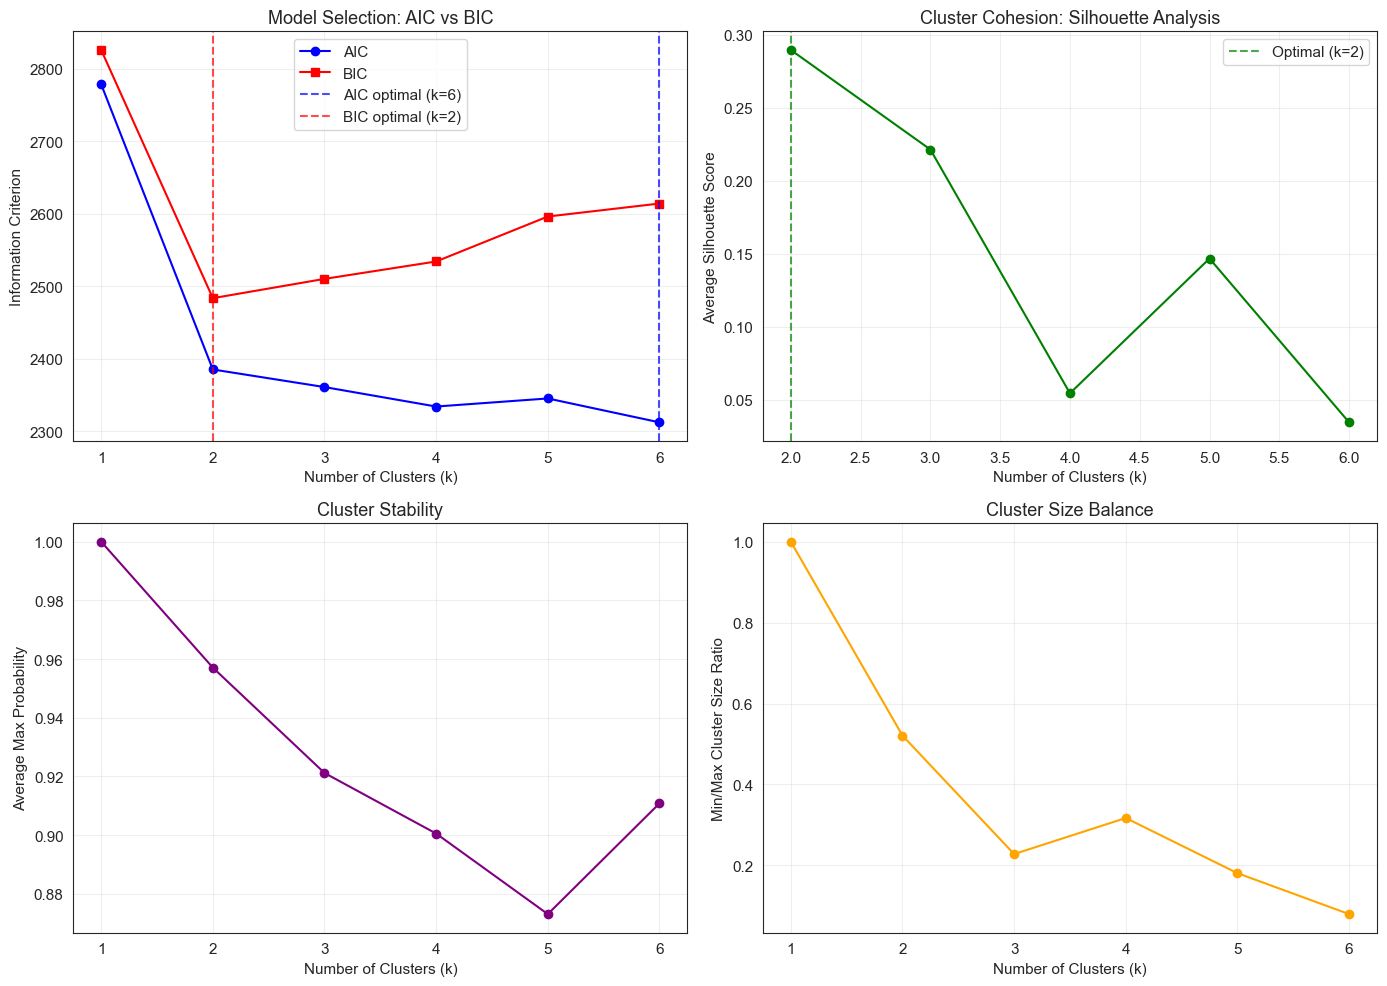


Detailed Results Table:
   k       AIC       BIC  Log_Likelihood  Silhouette  Stability  \
0  1  2778.434  2825.881          -6.280         NaN      1.000   
1  2  2385.438  2483.721          -5.314       0.290      0.957   
2  3  2361.191  2510.310          -5.190       0.221      0.921   
3  4  2334.354  2534.310          -5.060       0.054      0.901   
4  5  2345.488  2596.279          -5.017       0.147      0.873   
5  6  2312.551  2614.178          -4.873       0.035      0.911   

   Min_Cluster_Size  Max_Cluster_Size  
0               219               219  
1                75               144  
2                31               136  
3                26                82  
4                15                83  
5                 7                88  

Model Selection Summary:
• AIC prefers k = 6 clusters
• BIC prefers k = 2 clusters
• Silhouette analysis suggests k = 2 clusters

k=2 Performance (current choice):
• AIC: 2385.44
• BIC: 2483.72
• Silhouette: 0.290
• Stabilit

In [48]:
# GMM Model Selection: Optimal Number of Clusters for Polychoric Factors
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("GMM Model Selection for Polychoric Factor Clustering")
print("=" * 60)

# Prepare factor scores matrix
factor_scores_matrix_poly = factor_scores_poly_df[['PolyFactor1', 'PolyFactor2', 'PolyFactor3', 'PolyFactor4']].values
n_samples = factor_scores_matrix_poly.shape[0]

# Test different numbers of clusters
k_range = range(1, 7)  # Test 1-6 clusters
results = []

print(f"Testing k = 1 to 6 clusters on {n_samples} samples...")
print("\nModel Fitting Results:")
print("-" * 50)

for k in k_range:
    # Fit GMM with multiple random initializations for stability
    best_gmm = None
    best_aic = np.inf
    
    # Try multiple random seeds to find best fit
    for seed in [42, 123, 456, 789, 999]:
        gmm = GaussianMixture(n_components=k, random_state=seed, max_iter=200)
        gmm.fit(factor_scores_matrix_poly)
        
        if gmm.aic(factor_scores_matrix_poly) < best_aic:
            best_aic = gmm.aic(factor_scores_matrix_poly)
            best_gmm = gmm
    
    # Calculate metrics
    aic = best_gmm.aic(factor_scores_matrix_poly)
    bic = best_gmm.bic(factor_scores_matrix_poly)
    log_likelihood = best_gmm.score(factor_scores_matrix_poly)
    
    # Calculate silhouette score (only for k > 1)
    if k > 1:
        cluster_labels = best_gmm.predict(factor_scores_matrix_poly)
        silhouette_avg = silhouette_score(factor_scores_matrix_poly, cluster_labels)
        
        # Calculate cluster stability (average max probability)
        cluster_probs = best_gmm.predict_proba(factor_scores_matrix_poly)
        stability = np.mean(np.max(cluster_probs, axis=1))
        
        # Calculate cluster sizes
        unique, counts = np.unique(cluster_labels, return_counts=True)
        min_cluster_size = np.min(counts)
        max_cluster_size = np.max(counts)
        
    else:
        silhouette_avg = np.nan
        stability = 1.0  # Perfect stability for 1 cluster
        min_cluster_size = n_samples
        max_cluster_size = n_samples
    
    # Store results
    results.append({
        'k': k,
        'AIC': aic,
        'BIC': bic,
        'Log_Likelihood': log_likelihood,
        'Silhouette': silhouette_avg,
        'Stability': stability,
        'Min_Cluster_Size': min_cluster_size,
        'Max_Cluster_Size': max_cluster_size
    })
    
    print(f"k={k}: AIC={aic:.2f}, BIC={bic:.2f}, Silhouette={silhouette_avg:.3f}, Stability={stability:.3f}")

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Find optimal k for each criterion
print(f"\nOptimal Number of Clusters by Criterion:")
print("-" * 40)
optimal_aic = results_df.loc[results_df['AIC'].idxmin(), 'k']
optimal_bic = results_df.loc[results_df['BIC'].idxmin(), 'k']
optimal_silhouette = results_df.loc[results_df['Silhouette'].idxmax(), 'k']

print(f"AIC optimal: k = {optimal_aic}")
print(f"BIC optimal: k = {optimal_bic}")
print(f"Silhouette optimal: k = {optimal_silhouette}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AIC and BIC plot
ax1 = axes[0, 0]
ax1.plot(results_df['k'], results_df['AIC'], 'o-', label='AIC', color='blue')
ax1.plot(results_df['k'], results_df['BIC'], 's-', label='BIC', color='red')
ax1.axvline(x=optimal_aic, color='blue', linestyle='--', alpha=0.7, label=f'AIC optimal (k={optimal_aic})')
ax1.axvline(x=optimal_bic, color='red', linestyle='--', alpha=0.7, label=f'BIC optimal (k={optimal_bic})')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Information Criterion')
ax1.set_title('Model Selection: AIC vs BIC')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette score plot
ax2 = axes[0, 1]
silhouette_data = results_df[results_df['k'] > 1]  # Exclude k=1
ax2.plot(silhouette_data['k'], silhouette_data['Silhouette'], 'o-', color='green')
ax2.axvline(x=optimal_silhouette, color='green', linestyle='--', alpha=0.7, label=f'Optimal (k={optimal_silhouette})')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Cluster Cohesion: Silhouette Analysis')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Stability plot
ax3 = axes[1, 0]
ax3.plot(results_df['k'], results_df['Stability'], 'o-', color='purple')
ax3.set_xlabel('Number of Clusters (k)')
ax3.set_ylabel('Average Max Probability')
ax3.set_title('Cluster Stability')
ax3.grid(True, alpha=0.3)

# Cluster size balance plot
ax4 = axes[1, 1]
cluster_balance = results_df['Min_Cluster_Size'] / results_df['Max_Cluster_Size']
ax4.plot(results_df['k'], cluster_balance, 'o-', color='orange')
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Min/Max Cluster Size Ratio')
ax4.set_title('Cluster Size Balance')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display detailed results table
print(f"\nDetailed Results Table:")
print("=" * 80)
print(results_df.round(3))

# Summary and recommendation
print(f"\nModel Selection Summary:")
print("=" * 30)
print(f"• AIC prefers k = {optimal_aic} clusters")
print(f"• BIC prefers k = {optimal_bic} clusters") 
print(f"• Silhouette analysis suggests k = {optimal_silhouette} clusters")

# Find k=2 performance for comparison
k2_results = results_df[results_df['k'] == 2].iloc[0]
print(f"\nk=2 Performance (current choice):")
print(f"• AIC: {k2_results['AIC']:.2f}")
print(f"• BIC: {k2_results['BIC']:.2f}")
print(f"• Silhouette: {k2_results['Silhouette']:.3f}")
print(f"• Stability: {k2_results['Stability']:.3f}")

print(f"\nInterpretation:")
print("- Lower AIC/BIC = better fit")
print("- Higher Silhouette = better cluster separation")  
print("- Higher Stability = more confident cluster assignments")
print("- Balance ratio closer to 1.0 = more equally sized clusters")